# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
import os
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV, RidgeCV, LassoCV, Lasso
from scipy import stats

from popy.io_tools import *
from popy.behavior_data_tools import *
from popy.neural_data_tools import time_normalize_session, scale_neural_data, remove_low_fr_neurons, remove_trunctuated_neurons
from popy.decoding.decoder_tools import *
from popy.plotting.plotting_tools import *
#from popy.plotting.plot_behavior import show_target_selection 
import popy.config as cfg
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid

PATH = cfg.PROJECT_PATH_LOCAL


In [2]:
##% Plotting Functions

def plot_decoder_results(results, weights, n_extra_trials):
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))

    ax = axs[0]
    ax.plot(results.time, results)
    ax.axhline(.5, color='k', linestyle='--')
    
    plot_keypoints(ax, n_extra_trials, fontsize=8)
    ax.grid(axis='x')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('R2')
    ax.set_xlabel('Time')
    ax.set_title('R2 score')
    # add colorbar
    ax.set_title('decoder performance (cross val)')

    ax = axs[1]
    # plot bar below
    pbar = ax.imshow(weights.data.T, aspect='auto', cmap='RdBu', extent=[weights.time.min(), weights.time.max(), 0-.5, len(weights.unit)-.5], origin='lower', vmin=-np.max(np.abs(weights.data)*.5), vmax=np.max(np.abs(weights.data)*.5))
    plt.colorbar(pbar, ax=ax, pad=0.005, fraction=.05)
    
    plot_keypoints(ax, n_extra_trials, fontsize=8)
    ax.grid(axis='x', alpha=.5, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Time')
    ax.set_ylabel('Unit')
    ax.set_title('Weights')

    ax = axs[2]
    df_weights = get_weights_per_area(weights, t=3.5)
    plot_on_cortical_grid(df_weights, 'sum_weight_ratio', 
                            bar_title='percentage of weights given by area (%)',
                            ax=ax)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    return fig, axs

def plot_projected_data(data_projected, title, n_extra_trials, xlim=None):
    # project to axis
    h = 9  # in cm
    w = 12  # in cm

    fig, ax = plt.subplots(figsize=(w/2.54, h/2.54))

    time_vector = data_projected.time.values

    unique_fb_sequences = np.sort(np.unique(data_projected.fb_sequence.data))

    # bwr colormap, n=8 sampples RdYlGn
    colors = sns.color_palette("RdYlGn", len(unique_fb_sequences))[::-1]
    alphas = [1-i for i in np.linspace(0, 1, len(unique_fb_sequences))]
    labels = ["[-, -, -]", "[+, -, -]", "[-, +, -]", "[+, +, -]", "[-, -, +]", "[+, -, +]", "[-, +, +]", "[+, +, +]"][::-1]

    full_mean = np.mean(data_projected, axis=0)

    for i, label in enumerate(unique_fb_sequences[::-1]):
        class_mean = np.mean(data_projected.where(data_projected.fb_sequence == label), axis=0)
        ax.plot(time_vector, class_mean - full_mean, color=colors[i], label=labels[i], linewidth=1, alpha=.7)

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials)
    # y grid only
    ax.grid(axis='x', alpha=.5, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', alpha=.5)

    # remove left and top spines
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
    # move legemd outside
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('neural value')
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

def green_red_plot(data_projected):
    # distribution of pos and neg feedback along neural value
    fig, axs = plt.subplots(1, 4, figsize=(20, 6))

    V_t = data_projected.V_t.values
    V_t_m1 = data_projected.V_t_m1.values
    R_t_m1 = data_projected.R_1.values

    # get q_t and q_{t-1}
    q_curr = (V_t - np.min(V_t)) / (np.max(V_t) - np.min(V_t)) 
    q_prev = (V_t_m1 - np.min(V_t_m1)) / (np.max(V_t_m1) - np.min(V_t_m1))
    q_diff = q_curr - q_prev
    fb_vector = R_t_m1 
    fb_sequence = data_projected.fb_sequence.values

    ax = axs[0]

    # boxplot of q_curr: x axis is 8 levels of fb_sequence, y axis is q_curr (mean and std and also individual points are shown)
    sns.boxplot(x=fb_sequence, y=q_curr, palette='RdYlGn', ax=ax, hue=fb_sequence, legend=False)
    sns.stripplot(x=fb_sequence, y=q_curr, color='black', size=3, alpha=0.5, ax=ax)

    mean_val = np.mean(q_curr)
    ax.axhline(mean_val, color='k', linestyle='--', label='mean neural value')

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)

    ax.set_xlabel('Feedback sequence')
    ax.set_ylabel('Neural value at trial=t\n $V_t$')
    #ax.set_ylim(0, 1)
    # remove outliers
    ax.set_yticks([0, .5, 1])   
    ax.set_yticklabels([0, .5, 1])
    # legend
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    ax = axs[1]

    ax.hist(q_curr[fb_vector == 1], color='tab:green', alpha=.5, label='value after fb positive', bins=10)
    ax.hist(q_curr[fb_vector == 0], color='tab:red', alpha=.5, label='value after fb negative', bins=10)

    ax.axvline(mean_val, color='k', linestyle='--', label='mean neural value')
    # plot mean firing rate
    ax.set_xlabel('Neural value at trial=t\n $V_t$')
    #ax.set_xlim(0, 1)
    ax.set_ylabel('Count')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # distribution of change in value for each feedback
    ax = axs[2]

    ax.hist(q_diff[fb_vector == 1], color='tab:green', alpha=.5, label='value after fb positive', bins=10)
    ax.hist(q_diff[fb_vector == 0], color='tab:red', alpha=.5, label='value after fb negative', bins=10)
    # line at 0 and means
    ax.axvline(0, color='k', linestyle='-')
    ax.axvline(np.mean(q_diff[fb_vector == 1]), color='tab:green', linestyle='--', label='mean fb positive')
    ax.axvline(np.mean(q_diff[fb_vector == 0]), color='tab:red', linestyle='--', label='mean fb negative')

    ax.set_xlabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    #ax.set_xlim(-.7, .7)

    ax.set_ylabel('Count')
    # legend below plot
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axs[3]

    # change in value vs RPE
    RPE_neural = fb_vector - q_prev

    # scatter positive and negative RPEs and fit line
    q_prev_temp = q_prev[fb_vector == 1]
    q_diff_temp = q_diff[fb_vector == 1]
    ax.scatter(q_prev[fb_vector == 1], q_diff[fb_vector == 1], color='tab:green', alpha=.5)
    # fit line
    slope, intercept, r_value, p_value, std_err = stats.linregress(q_prev_temp, q_diff_temp)
    fit_line = slope * q_prev_temp + intercept
    ax.plot(q_prev_temp, fit_line, color='tab:green', alpha=.5)

    # scatter negative RPEs
    q_prev_temp = q_prev[fb_vector == 0]
    q_diff_temp = q_diff[fb_vector == 0]
    ax.scatter(q_prev[fb_vector == 0], q_diff[fb_vector == 0], color='tab:red', alpha=.5)
    # fit line
    slope, intercept, r_value, p_value, std_err = stats.linregress(q_prev_temp, q_diff_temp)
    fit_line = slope * q_prev_temp + intercept
    ax.plot(q_prev_temp, fit_line, color='tab:red', alpha=.5)


    # line at 0
    ax.axvline(mean_val, color='k', linestyle='--')
    ax.axhline(0, color='k', linestyle='-')
    # legend
    ax.scatter([], [], color='tab:green', label='fb positive')
    ax.scatter([], [], color='tab:red', label='fb negative')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.set_xlabel('Neural value at trial t-1\n $V_{t-1}$')
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    #ax.set_ylim(-np.max(np.abs(q_diff))*1.1, np.max(np.abs(q_diff))*1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # both axes from -1 to 1

    plt.tight_layout()

    return fig, axs

def plot_res_all(results_df, monkey, session, area):
    from scipy import stats

    # histogram of deltas: 0 and 1
    # top plot is half of the bottom plot in height
    fig, axs = plt.subplots(3, 2, figsize=(8, 12), gridspec_kw={'height_ratios': [1, 1, 2]}, sharey='row')
    plt.suptitle(f'Distribution of dVs for same and alter trials\n monkey {monkey}, session {session}, area {area}')

    bins = np.linspace(-.7, .7, 20)

    plt.xlim(-.7, .7)

    # plot boxplot: dV for positive and negative feedback (negative on left with boxplot of red, positive on the right with boxplot of green)
    ax = axs[0, 0]

    # Create the boxplot with narrower bars
    sns.boxplot(
        data=results_df.loc[results_df['type'] == 'within'], 
        x='R_1',
        y='dV',
        hue='R_1',  # Added hue parameter
        palette={0: 'tab:red', 1: 'tab:green'},
        ax=ax,
        width=0.7,
        legend=False,  # Hide the legend
        boxprops=dict(alpha=0.7),
    )

    # Add individual data points using stripplot
    '''sns.stripplot(
        data=results_df.loc[results_df['type'] == 'within'], 
        x='R_1',
        y='dV',
        hue='R_1',  # Added hue parameter
        palette={0: 'tab:red', 1: 'tab:green'},
        edgecolor='black', 
        linewidth=1,
        size=3,
        alpha=0.5,
        ax=ax,
        jitter=True,
        legend=False  # Hide the legend
    )'''

    # Perform t-test between the two conditions
    neg_values = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV']
    pos_values = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV']
    t_stat, p_value = stats.ttest_ind(neg_values, pos_values)

    # Determine y position for the significance bar (slightly above the highest point)
    y_max = max(results_df.loc[results_df['type'] == 'within', 'dV'].max(), 
            neg_values.max(), 
            pos_values.max())
    y_pos = y_max + 0.1 * abs(y_max)

    # Add significance annotation
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'n.s.'

    # Add the bar and text for p-value
    ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
    ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
            ha='center', va='bottom', fontsize=10)

    ax.axhline(0, linestyle='--', alpha=.7, color='black')
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_xlabel('')
    ax.set_xlim(-1, 2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Within target')


    ax = axs[0, 1]

    # Create the boxplot with narrower bars
    sns.boxplot(
        data=results_df.loc[results_df['type'] == 'alter'], 
        x='R_1',
        y='dV',
        hue='R_1',  # Added hue parameter
        palette={0: 'tab:red', 1: 'tab:green'},
        ax=ax,
        width=0.7,  # Make bars less wide (default is 0.8)
        boxprops=dict(alpha=0.7),
        legend=False
    )

    # Add individual data points using stripplot
    '''sns.stripplot(
        data=results_df.loc[results_df['type'] == 'alter'], 
        x='R_1',
        y='dV',
        hue='R_1',  # Added hue parameter
        palette={0: 'tab:red', 1: 'tab:green'},
        edgecolor='black', 
        linewidth=1,
        size=3,
        alpha=0.5,
        ax=ax,
        jitter=True,
        legend=False  # Hide the legend
    )'''

    # Perform t-test between the two conditions
    neg_values = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV']
    pos_values = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV']
    t_stat, p_value = stats.ttest_ind(neg_values, pos_values)

    # Determine y position for the significance bar (slightly above the highest point)
    y_max = max(results_df.loc[results_df['type'] == 'alter', 'dV'].max(), 
            neg_values.max(), 
            pos_values.max())
    y_pos = y_max + 0.1 * abs(y_max)

    # Add significance annotation
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'n.s.'


    # Add the bar and text for p-value
    ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
    ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
            ha='center', va='bottom', fontsize=10)

    ax.axhline(0, linestyle='--', alpha=.7, color='black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_xlabel('')
    ax.set_xlim(-.5, 1.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Within target')


    ax = axs[1, 0]
    ax.hist(results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV'], color='tab:red', alpha=.5, label='negative feedback', bins=bins)
    ax.hist(results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV'], color='tab:green', alpha=.5, label='positive feedback', bins=bins)
    ax.axvline(0, color='k', linestyle='--')
    ax.set_xlabel('$\Delta V = V_t - V_{t-1}$')
    ax.set_ylabel('# trials')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Within target')

    ax = axs[1, 1]
    ax.hist(results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV'], color='tab:red', alpha=.5, label='Rewarded', bins=bins)
    ax.hist(results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV'], color='tab:green', alpha=.5, label='Unrewarded', bins=bins)
    ax.axvline(0, color='k', linestyle='--')
    ax.set_xlabel('$\Delta V = V_t - V_{t-1}$')
    ax.set_ylabel('# trials')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title('Across target')

    ax = axs[2, 0]
    x_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV']
    y_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'dV_behav']
    ax.scatter(x_neg_within, y_neg_within, color='tab:red', alpha=.5, label='Unrewarded')
    line = np.polyfit(x_neg_within, y_neg_within, 1)
    ax.plot(x_neg_within, line[0] * x_neg_within + line[1], color='tab:red', alpha=1)

    x_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV']
    y_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'dV_behav']
    ax.scatter(x_pos_within, y_pos_within, color='tab:green', alpha=.5, label='Rewarded')
    line = np.polyfit(x_pos_within, y_pos_within, 1)
    ax.plot(x_pos_within, line[0] * x_pos_within + line[1], color='tab:green', alpha=1)

    x_all_within = results_df.loc[(results_df['type'] == 'within'), 'dV']
    y_all_within = results_df.loc[(results_df['type'] == 'within'), 'dV_behav']
    line = np.polyfit(x_all_within, y_all_within, 1)
    ax.plot(x_all_within, line[0] * x_all_within + line[1], color='black', alpha=1)

    ax.axvline(0, color='k', linestyle='--', alpha=.5)
    ax.axhline(0, color='k', linestyle='--', alpha=.5)
    ax.set_xlabel('$\Delta V_{neural} = V_t - V_{t-1}$')
    ax.set_ylabel('$\Delta V_{behav} = V_t - V_{t-1}$')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axs[2, 1]
    x_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV']
    y_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV_behav']
    ax.scatter(x_neg_alter, y_neg_alter, color='tab:red', alpha=.5, label='Unrewarded')
    line = np.polyfit(x_neg_alter, y_neg_alter, 1)
    ax.plot(x_neg_alter, line[0] * x_neg_alter + line[1], color='tab:red', alpha=1)

    x_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV']
    y_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV_behav']
    ax.scatter(x_pos_alter, y_pos_alter, color='tab:green', alpha=.5, label='Rewarded')
    line = np.polyfit(x_pos_alter, y_pos_alter, 1)
    ax.plot(x_pos_alter, line[0] * x_pos_alter + line[1], color='tab:green', alpha=1)

    x_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'dV']
    y_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'dV_behav']
    line = np.polyfit(x_all_alter, y_all_alter, 1)
    ax.plot(x_all_alter, line[0] * x_all_alter + line[1], color='black', alpha=1)

    ax.axvline(0, color='k', linestyle='--', alpha=.5)
    ax.axhline(0, color='k', linestyle='--', alpha=.5)
    ax.set_xlabel('$\Delta V_{neural} = V_t - V_{t-1}$')
    ax.set_ylabel('$\Delta V_{behav} = V_t - V_{t-1}$')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()


---
# Get data

In [3]:
from popy.config import PROJECT_PATH_LOCAL as PATH

path = f'{PATH}/redgreen.csv'

results_df_all = pd.read_csv(path, dtype={'unit': str, 'area': str, 'session': str})
# sort by monkey session trial_id target type
results_df_all = results_df_all.sort_values(by=['monkey', 'session', 'trial_id', 'target', 'type'])
results_df_all

,monkey,session,trial_id,target,type,R_1,V_neural,V_behav,dV,dV_behav
42782,ka,010720,1,1.0,alter,1,0.170987,0.479459,-0.168181,0.361184
42783,ka,010720,1,2.0,alter,1,0.088480,0.479459,-0.000777,0.361184
42784,ka,010720,1,3.0,within,1,0.124963,0.479459,-0.176720,0.361184
42785,ka,010720,2,2.0,alter,0,0.040548,0.283056,-0.047932,-0.196402
42786,ka,010720,3,1.0,within,1,0.080178,0.479459,-0.023545,0.196402
...,...,...,...,...,...,...,...,...,...,...
33518,po,310822,422,2.0,alter,1,-0.135616,0.719282,-0.063802,0.122495
33519,po,310822,422,3.0,alter,1,-0.064222,0.719282,-0.018439,0.122495
33520,po,310822,423,1.0,within,1,-0.088406,0.804564,-0.077530,0.085282
33521,po,310822,423,2.0,alter,1,-0.060222,0.804564,0.075394,0.085282


In [7]:
res = []

for monkey in results_df_all.monkey.unique():
    for session in results_df_all.session.unique():
        results_df = results_df_all.loc[(results_df_all['monkey'] == monkey) & (results_df_all['session'] == session)]

        # Perform t-test between the two conditions
        neg_values = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'dV']
        pos_values = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'dV']
        t_stat, p_value = stats.ttest_ind(neg_values, pos_values)

        mean_pos = np.mean(pos_values)
        mean_neg = np.mean(neg_values)
        mean_diff = mean_pos - mean_neg

        res.append({
            'monkey': monkey,
            'session': session,
            'mean_pos': mean_pos,
            'mean_neg': mean_neg,
            'mean_diff': mean_diff,
            't_stat': t_stat,
            'p_value': p_value
        })

# Convert the results to a DataFrame
res = pd.DataFrame(res)
res = res.dropna()
res

/Users/zsombi/anaconda3/envs/popy_local/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


,monkey,session,mean_pos,mean_neg,mean_diff,t_stat,p_value
0,ka,010720,0.005770,-0.005220,0.010990,-1.053591,2.923629e-01
1,ka,010822,0.003250,0.001463,0.001787,-0.134328,8.931805e-01
2,ka,010922,0.011930,-0.016276,0.028206,-0.666816,5.052732e-01
3,ka,011020,0.021229,-0.045805,0.067034,-2.266967,2.393214e-02
4,ka,020622,0.071922,-0.085294,0.157216,-9.669768,1.009539e-20
...,...,...,...,...,...,...,...
211,po,280722,-0.004466,0.004289,-0.008755,0.284591,7.760293e-01
212,po,291020,0.006504,-0.008745,0.015248,-0.611137,5.416446e-01
213,po,300322,-0.000139,-0.000163,0.000023,-0.007243,9.942231e-01
214,po,300421,0.005657,-0.014318,0.019975,-1.581204,1.142864e-01


In [23]:
res[res['p_value'] < plim]

,monkey,session,mean_pos,mean_neg,mean_diff,t_stat,p_value
3,ka,011020,0.021229,-0.045805,0.067034,-2.266967,2.393214e-02
4,ka,020622,0.071922,-0.085294,0.157216,-9.669768,1.009539e-20
5,ka,030322,0.025258,-0.030339,0.055597,-4.616899,4.528195e-06
6,ka,030522,0.005686,-0.009164,0.014850,-2.279132,2.292384e-02
7,ka,040321,0.037010,-0.052460,0.089470,-6.561970,9.495170e-11
9,ka,050422,0.017419,-0.023987,0.041406,-3.465292,5.581497e-04
10,ka,050620,0.049458,-0.051763,0.101220,-6.743756,2.471692e-11
13,ka,080620,0.005888,-0.007796,0.013685,-2.817949,4.963865e-03
25,ka,150221,0.019797,-0.034271,0.054069,-3.380306,7.590110e-04
26,ka,150622,0.015428,-0.020065,0.035493,-2.985593,2.924526e-03


In [26]:
# print hom many sessions are significant, per monkey
plim = 0.05
print(f'number of sessions significant (p < {plim}):\n')
for monkey in res.monkey.unique():
    n_sessions = len(res.loc[res['monkey'] == monkey])
    n_sessions_significant = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim)])
    n_sessions_significant_neg = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim) & (res['mean_diff'] < 0)])
    n_sessions_significant_pos = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim) & (res['mean_diff'] > 0)])

    n_sessions_negative_after_negative = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim) & (res['mean_neg'] < 0)])
    n_sessions_negative_after_positive = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim) & (res['mean_pos'] < 0)])
    n_sessions_positive_after_negative = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim) & (res['mean_neg'] > 0)])
    n_sessions_positive_after_positive = len(res.loc[(res['monkey'] == monkey) & (res['p_value'] < plim) & (res['mean_pos'] > 0)])

    print(f'monkey {monkey}')
    print(f'sessions where dV after Unrewarded and Rewarded are significantly different (ttest): {n_sessions_significant} / {n_sessions}')
    print('')
    print(f'Num. sess.: dV after Unrewarded > dV after Rewarded: {n_sessions_significant_neg} / {n_sessions_significant}')
    print(f'Num. sess.: dV after Unrewarded < dV after Rewarded: {n_sessions_significant_pos} / {n_sessions_significant}')
    print('')
    print(f'Num. sess.: dV after Unrewarded < 0: {n_sessions_negative_after_negative} / {n_sessions_significant}')
    print(f'Num. sess.: dV after Rewarded < 0: {n_sessions_negative_after_positive} / {n_sessions_significant}')
    print(f'Num. sess.: dV after Unrewarded > 0: {n_sessions_positive_after_negative} / {n_sessions_significant}')
    print(f'Num. sess.: dV after Rewarded > 0: {n_sessions_positive_after_positive} / {n_sessions_significant}')
    print('---')

number of sessions significant (p < 0.05):

monkey ka
sessions where dV after Unrewarded and Rewarded are significantly different (ttest): 24 / 57

Num. sess.: dV after Unrewarded > dV after Rewarded: 0 / 24
Num. sess.: dV after Unrewarded < dV after Rewarded: 24 / 24

Num. sess.: dV after Unrewarded < 0: 24 / 24
Num. sess.: dV after Rewarded < 0: 0 / 24
Num. sess.: dV after Unrewarded > 0: 0 / 24
Num. sess.: dV after Rewarded > 0: 24 / 24
---
monkey po
sessions where dV after Unrewarded and Rewarded are significantly different (ttest): 9 / 51

Num. sess.: dV after Unrewarded > dV after Rewarded: 1 / 9
Num. sess.: dV after Unrewarded < dV after Rewarded: 8 / 9

Num. sess.: dV after Unrewarded < 0: 8 / 9
Num. sess.: dV after Rewarded < 0: 1 / 9
Num. sess.: dV after Unrewarded > 0: 1 / 9
Num. sess.: dV after Rewarded > 0: 8 / 9
---


/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_30382/1371997830.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unrewarded', 'Rewarded'])
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_30382/1371997830.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unrewarded', 'Rewarded'])
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_30382/1371997830.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Unrewarded', 'Rewarded'])
/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_30382/1371997830.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.

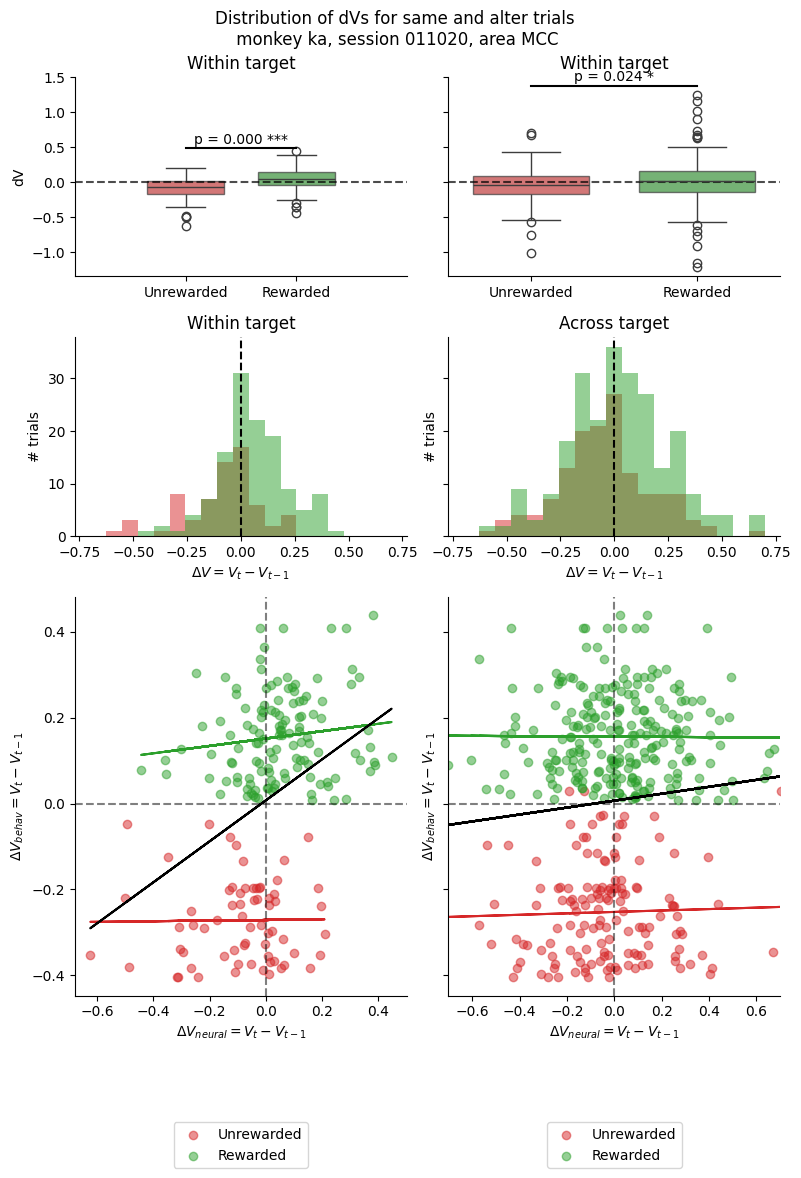

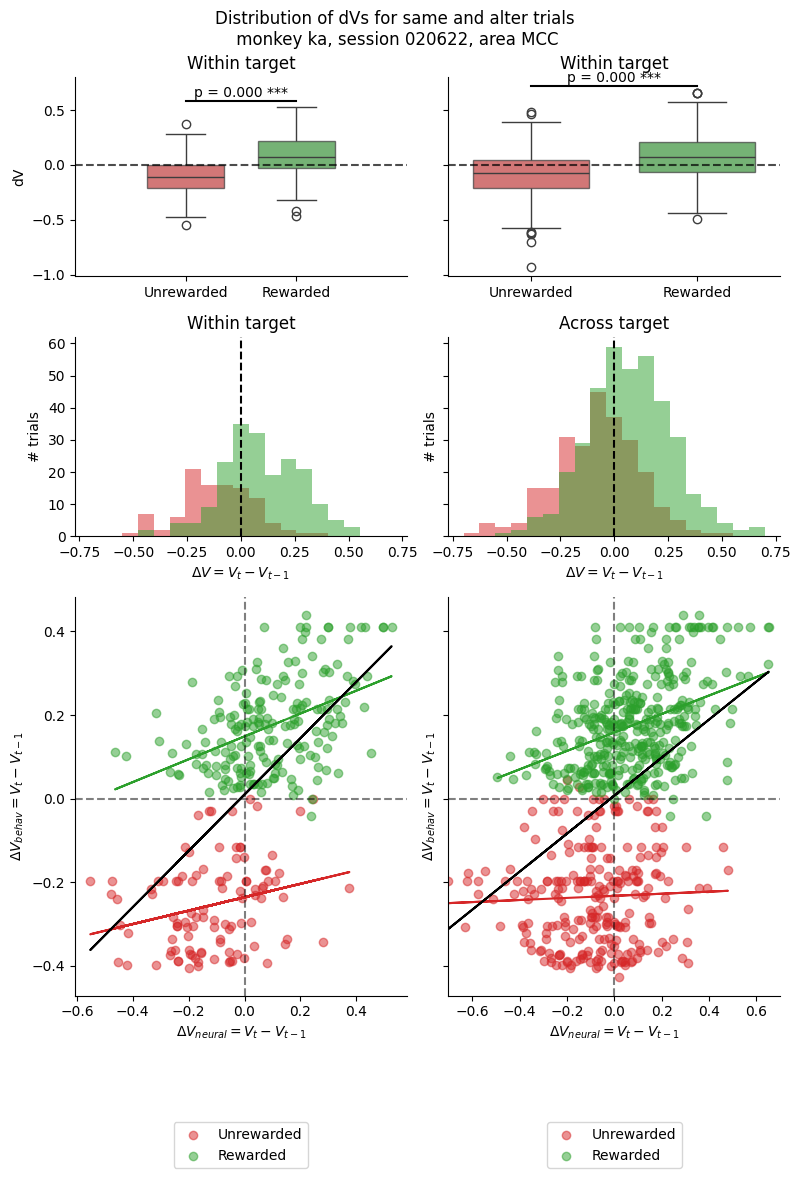

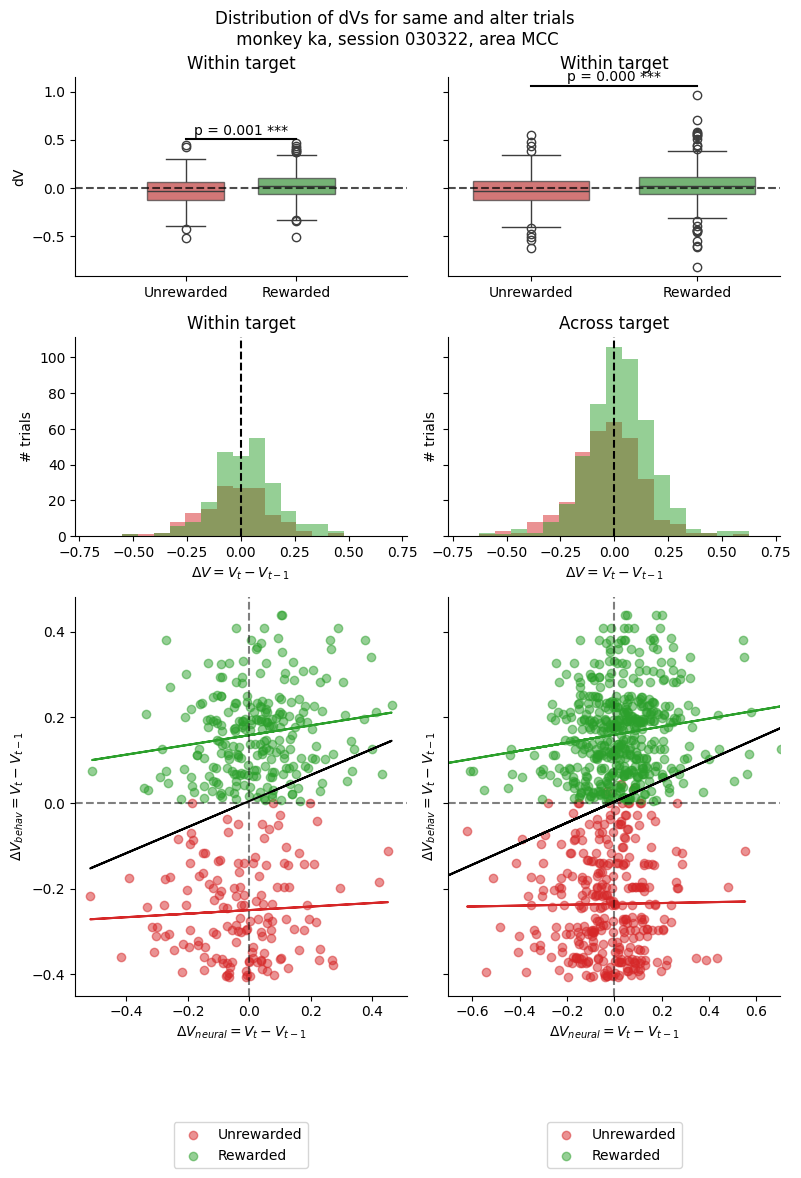

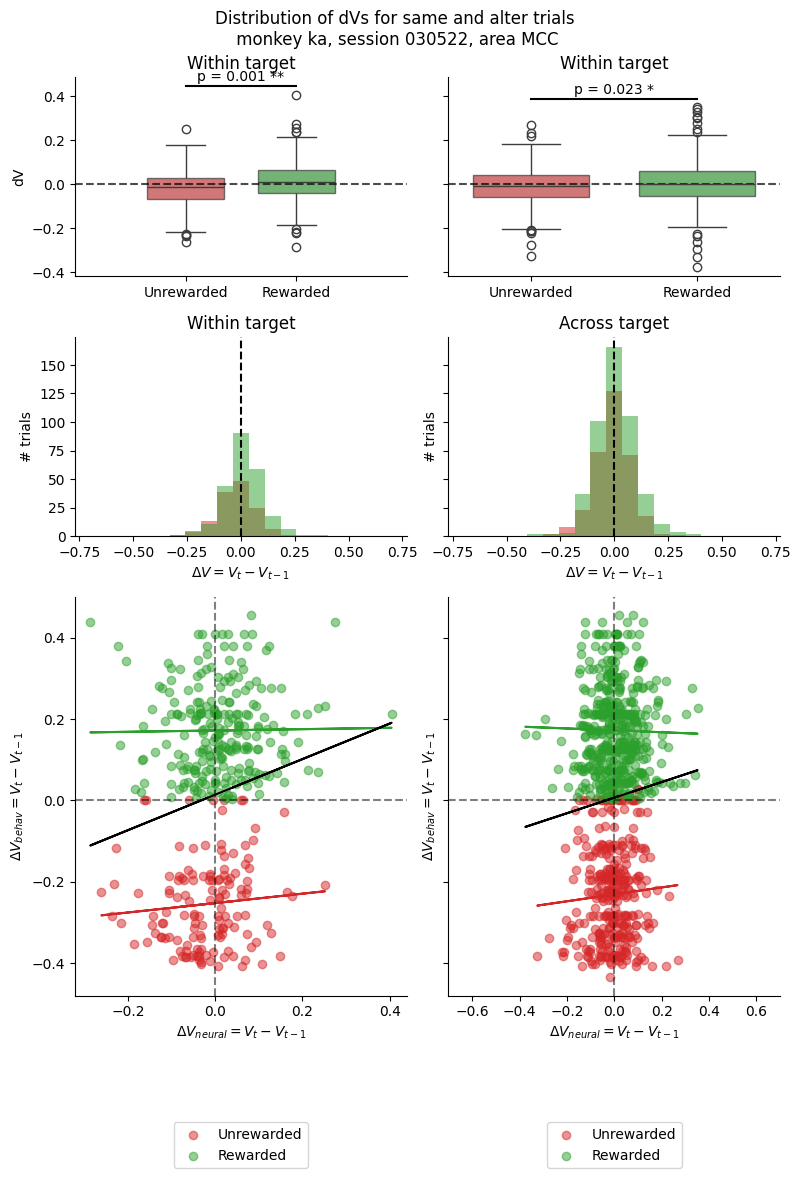

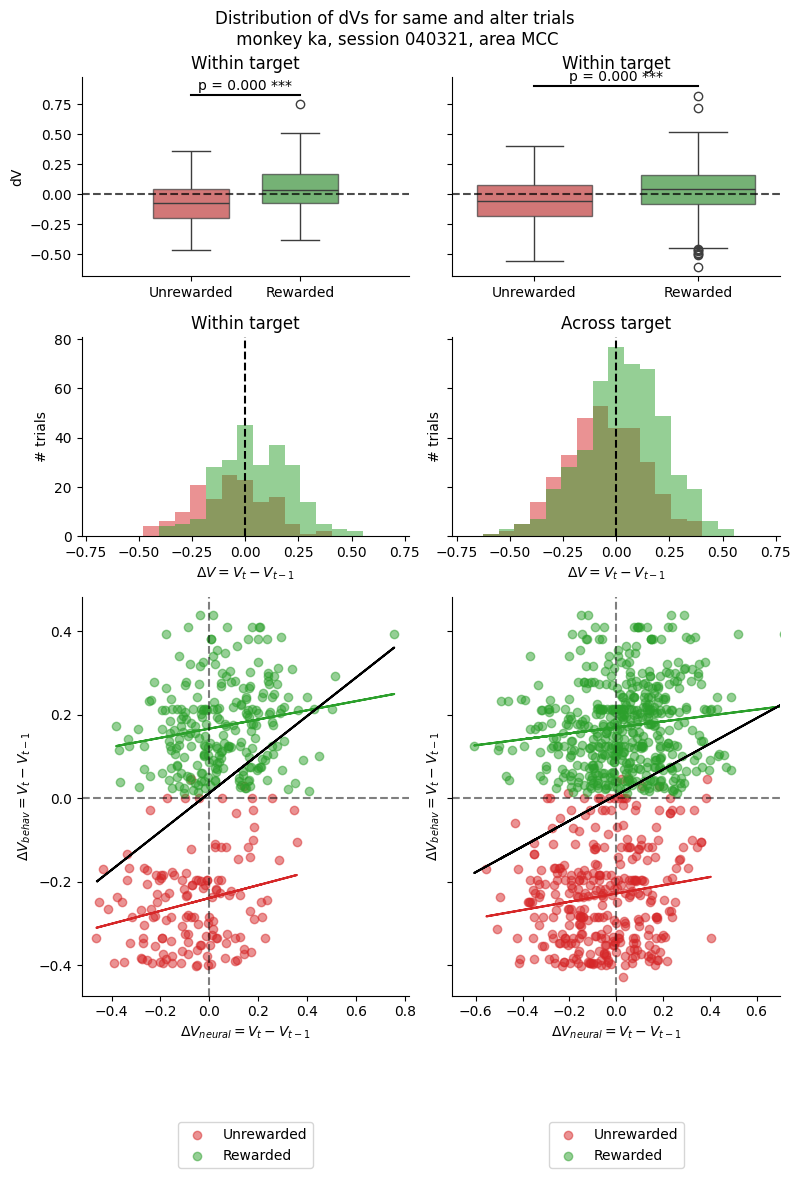

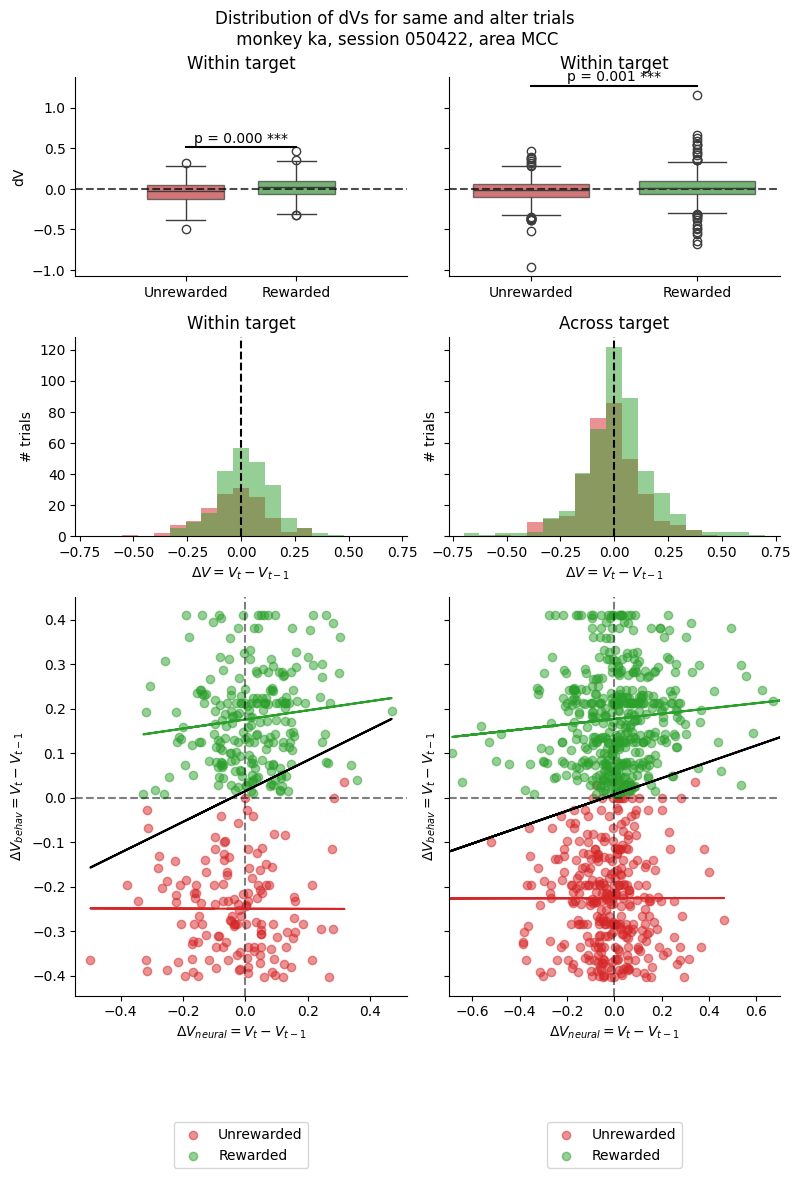

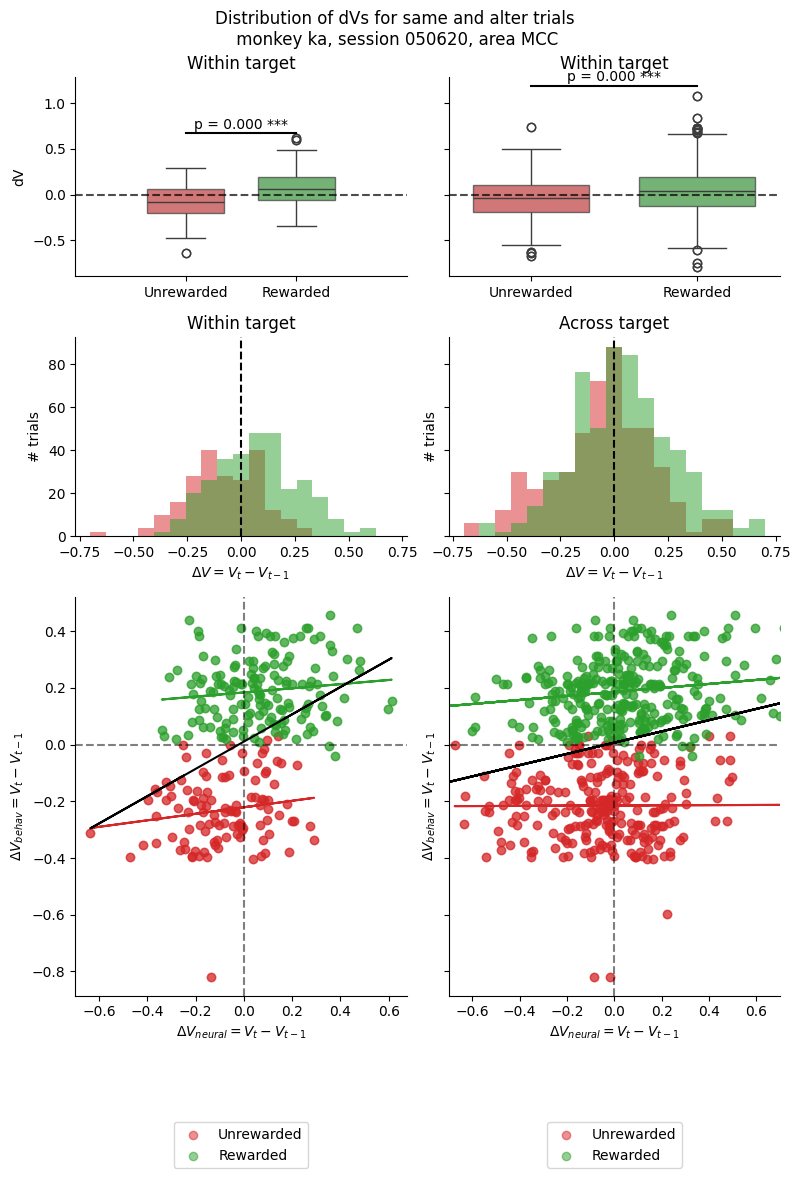

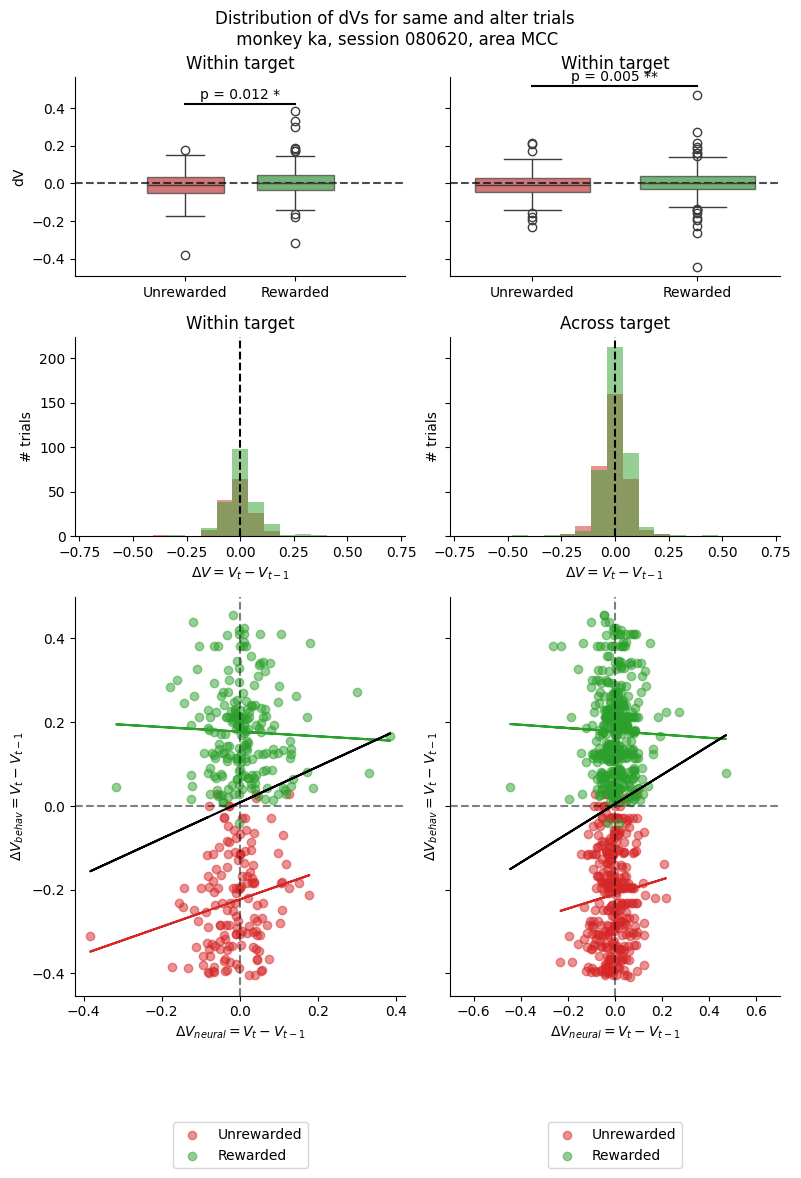

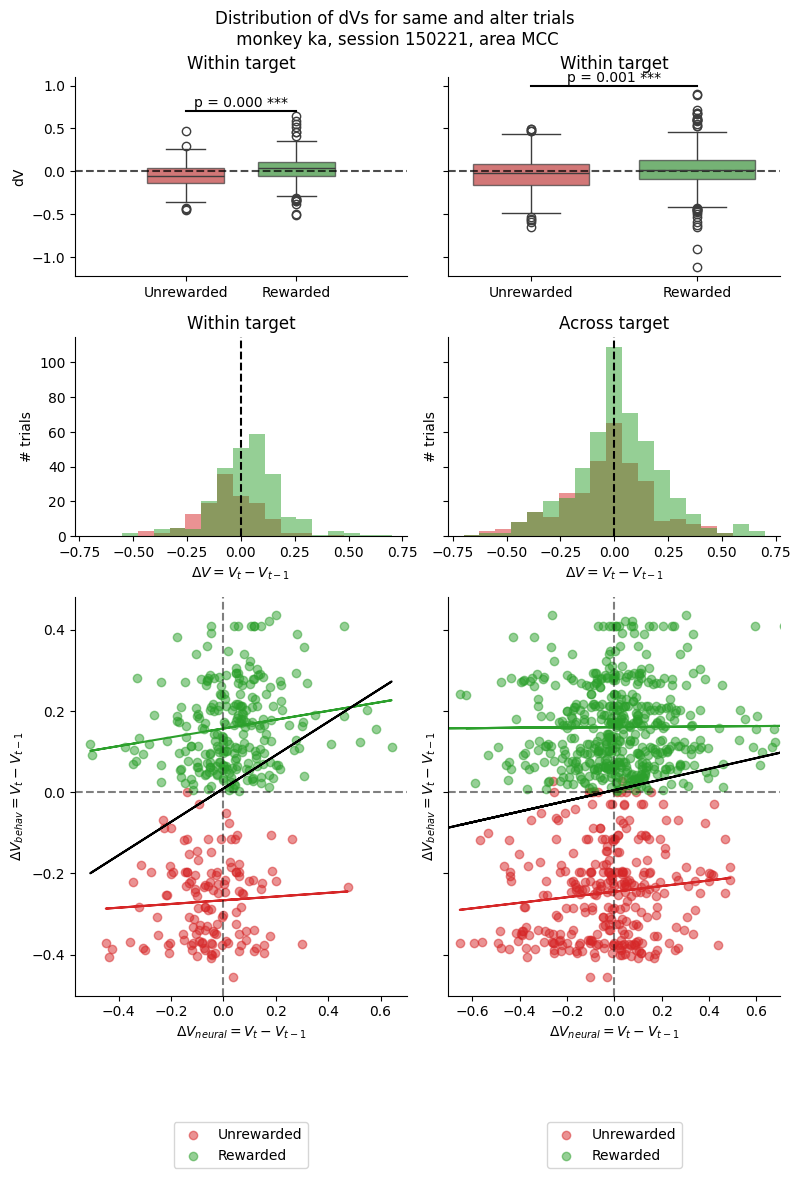

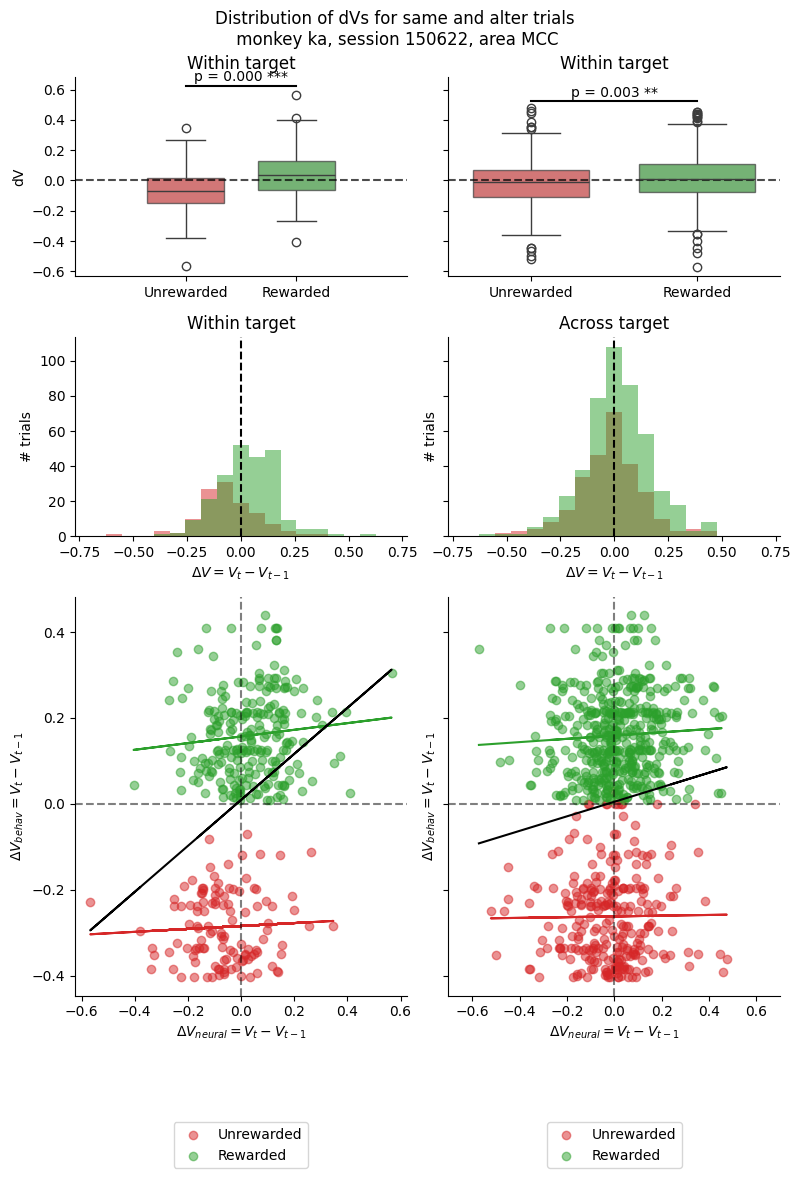

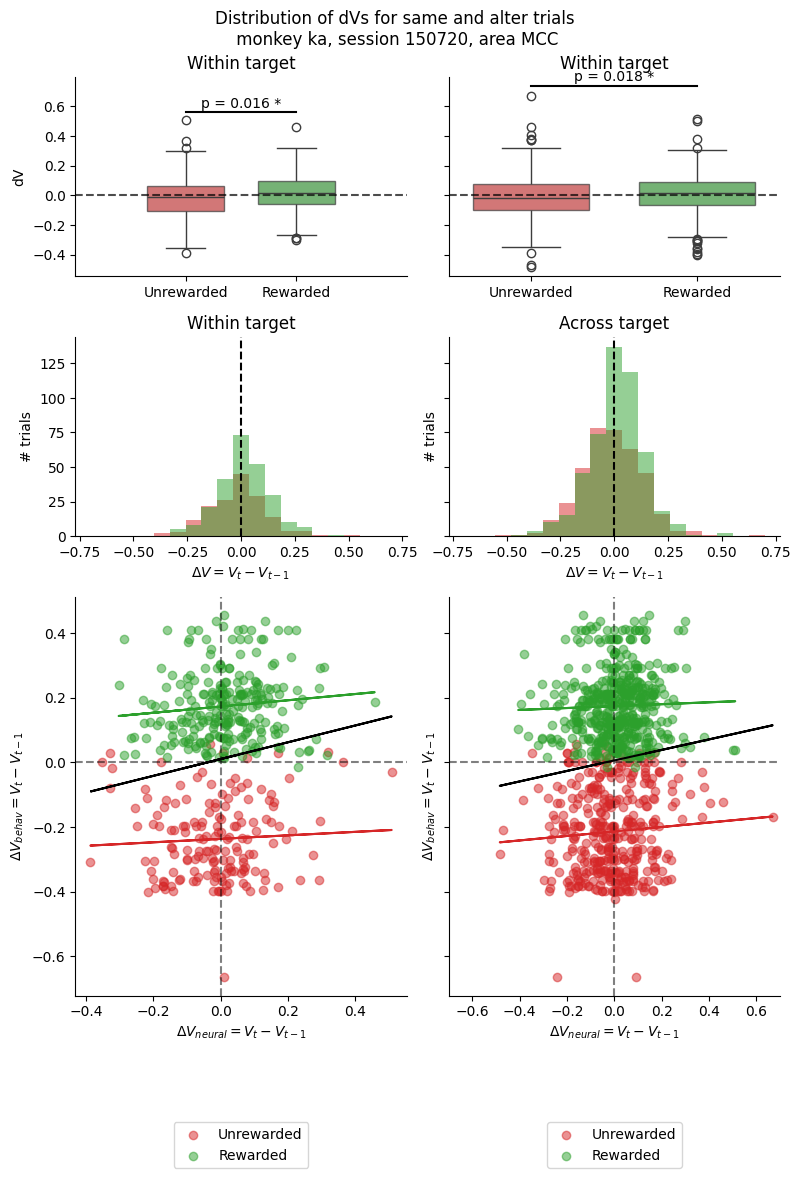

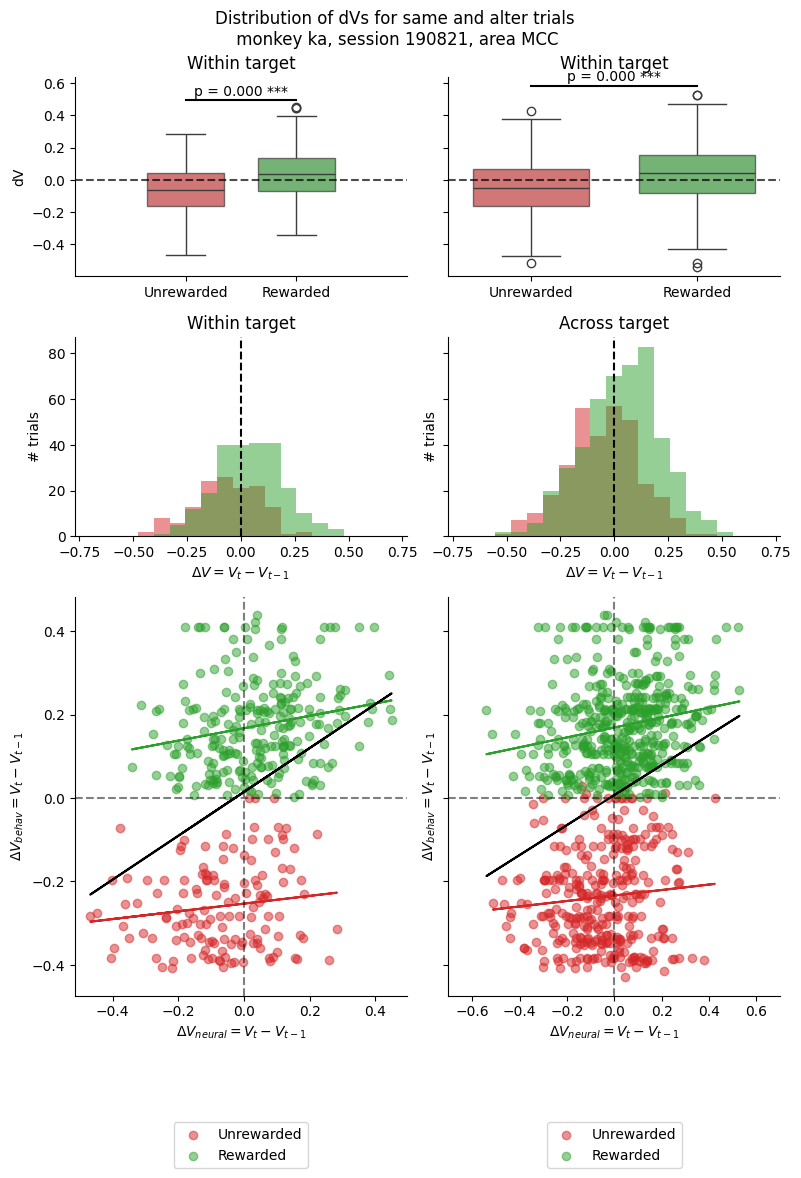

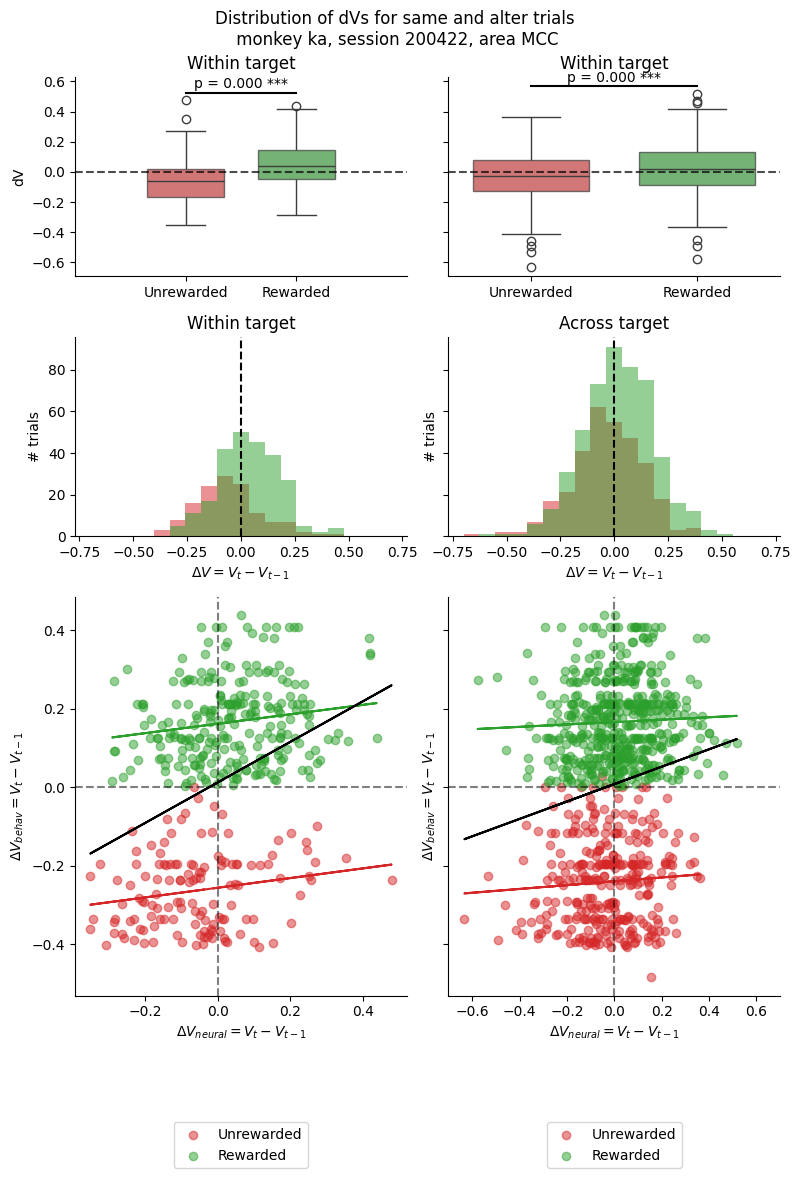

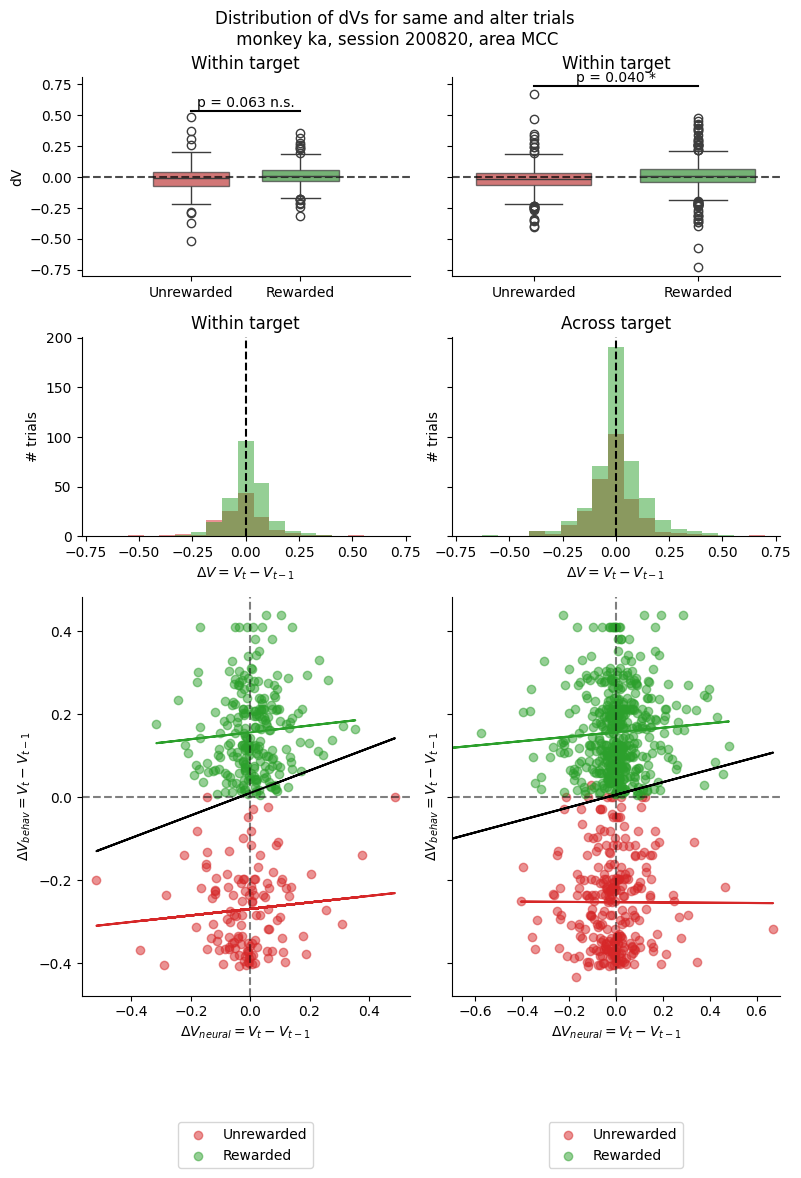

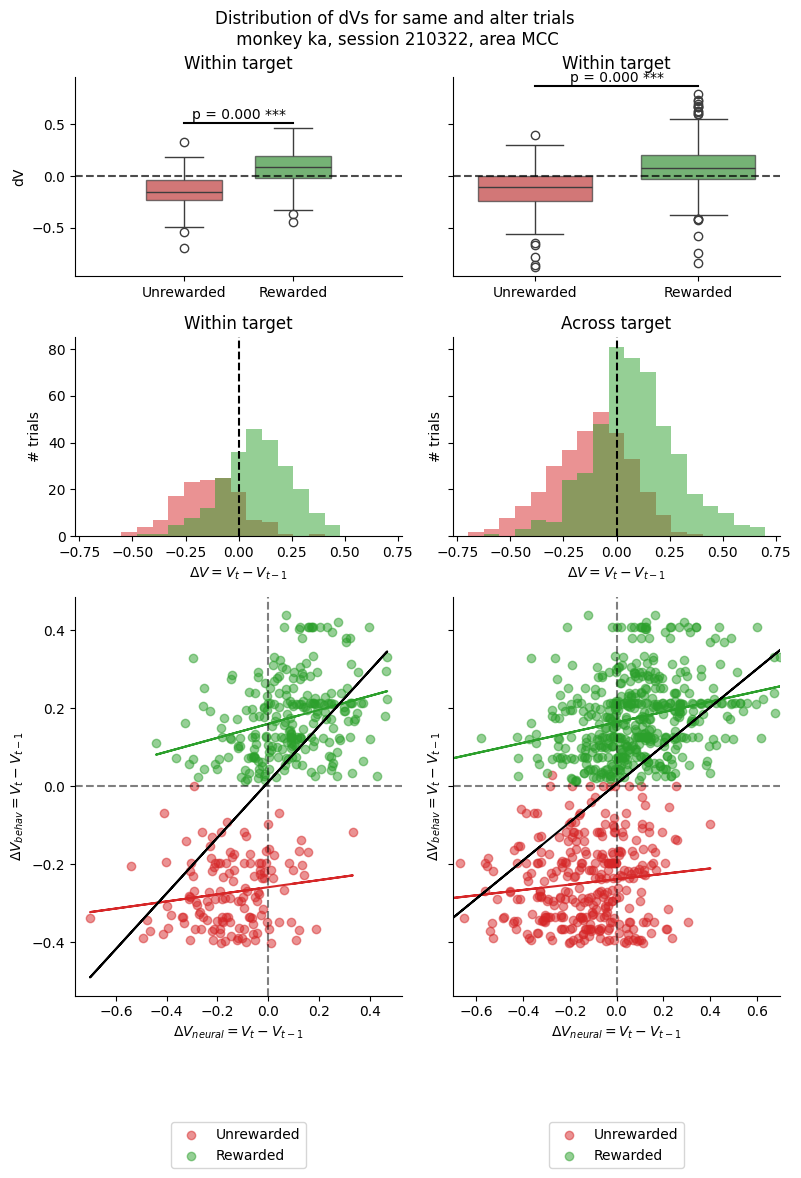

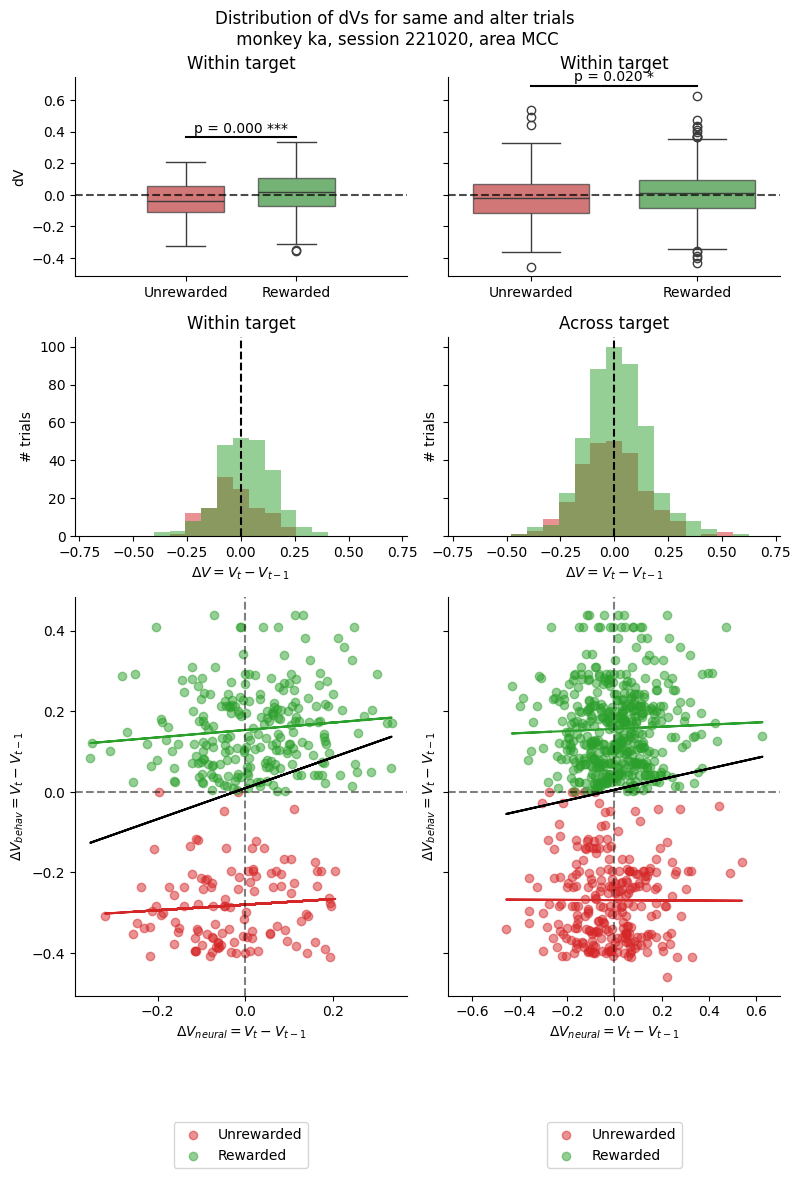

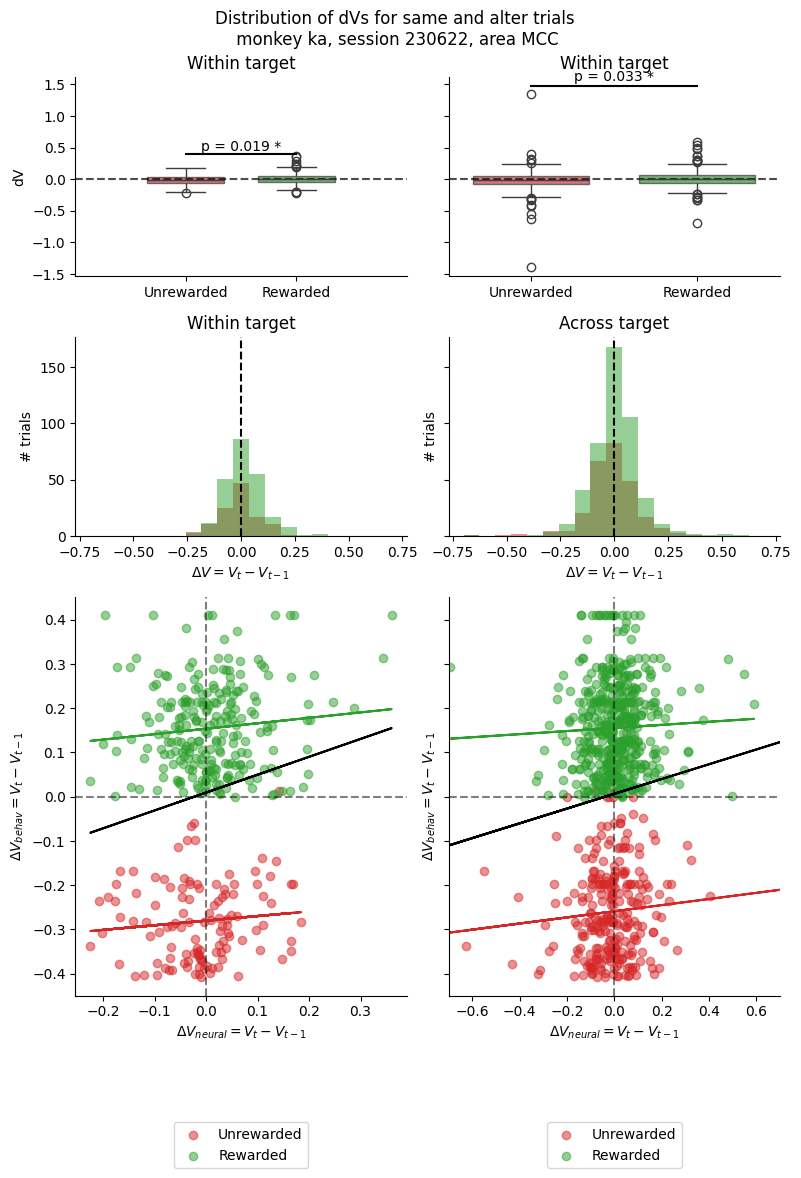

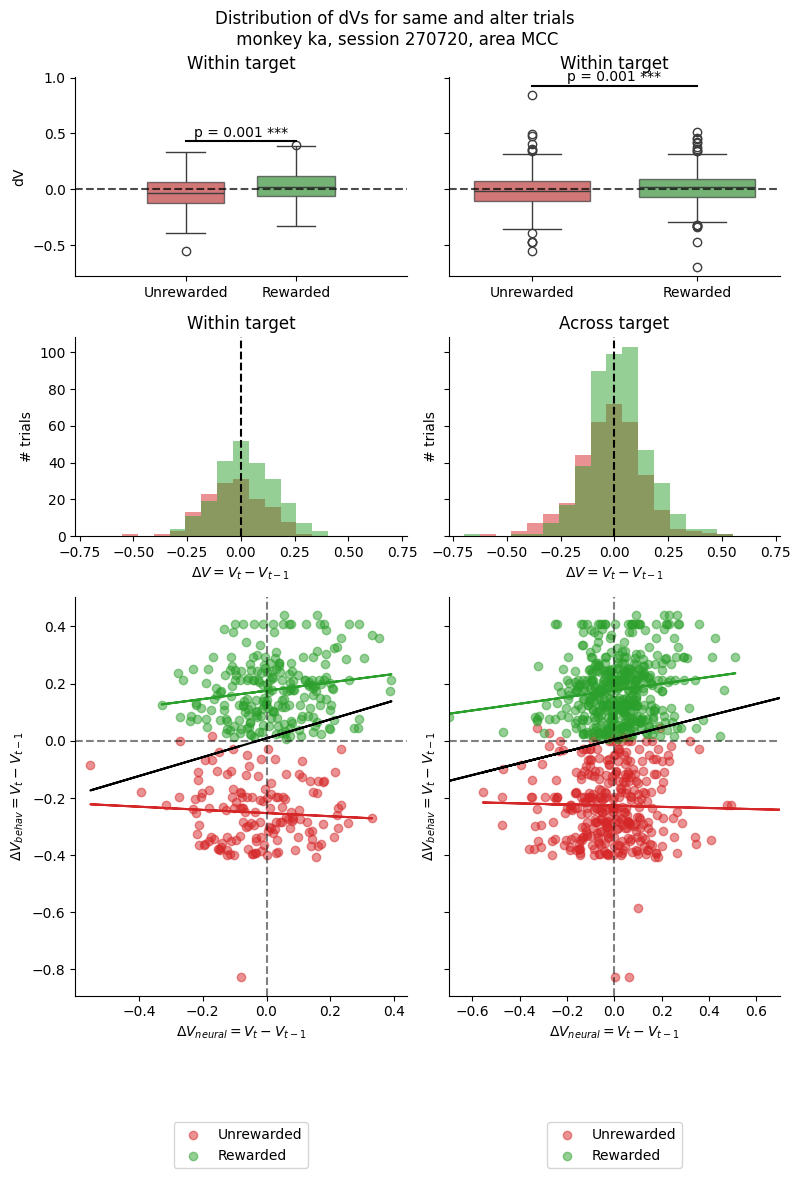

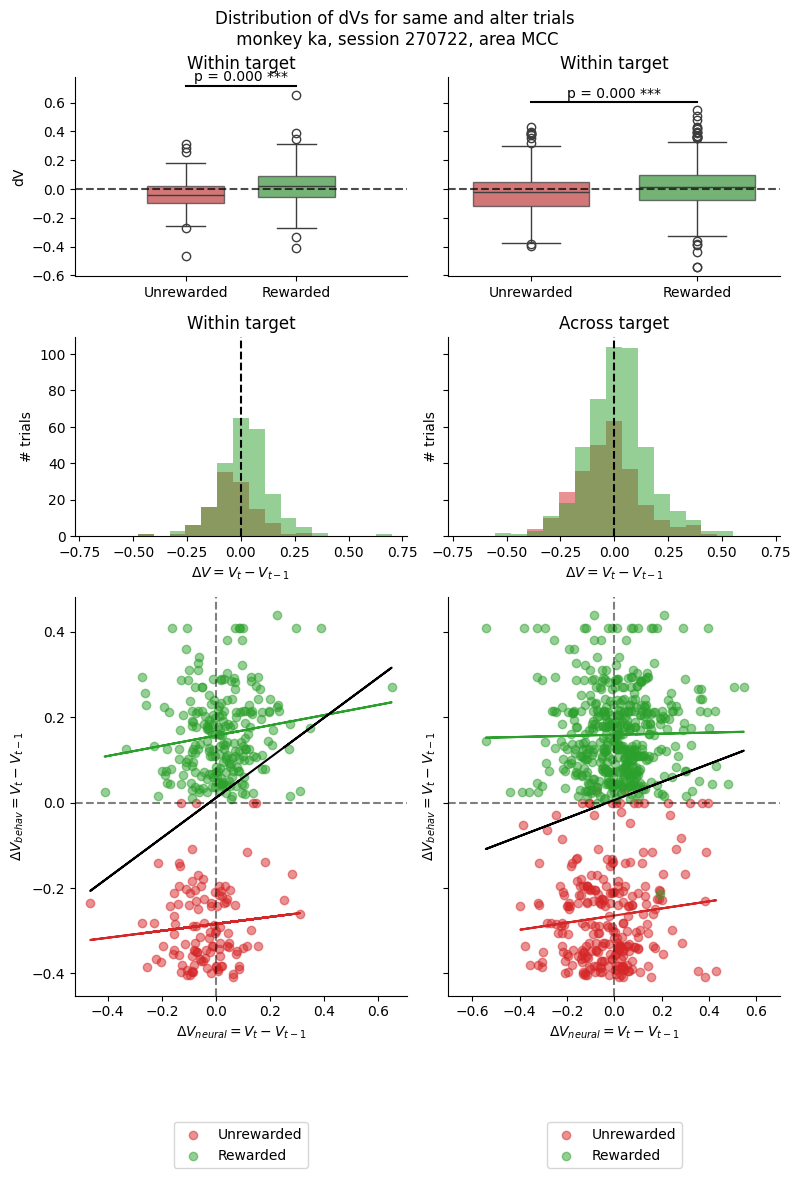

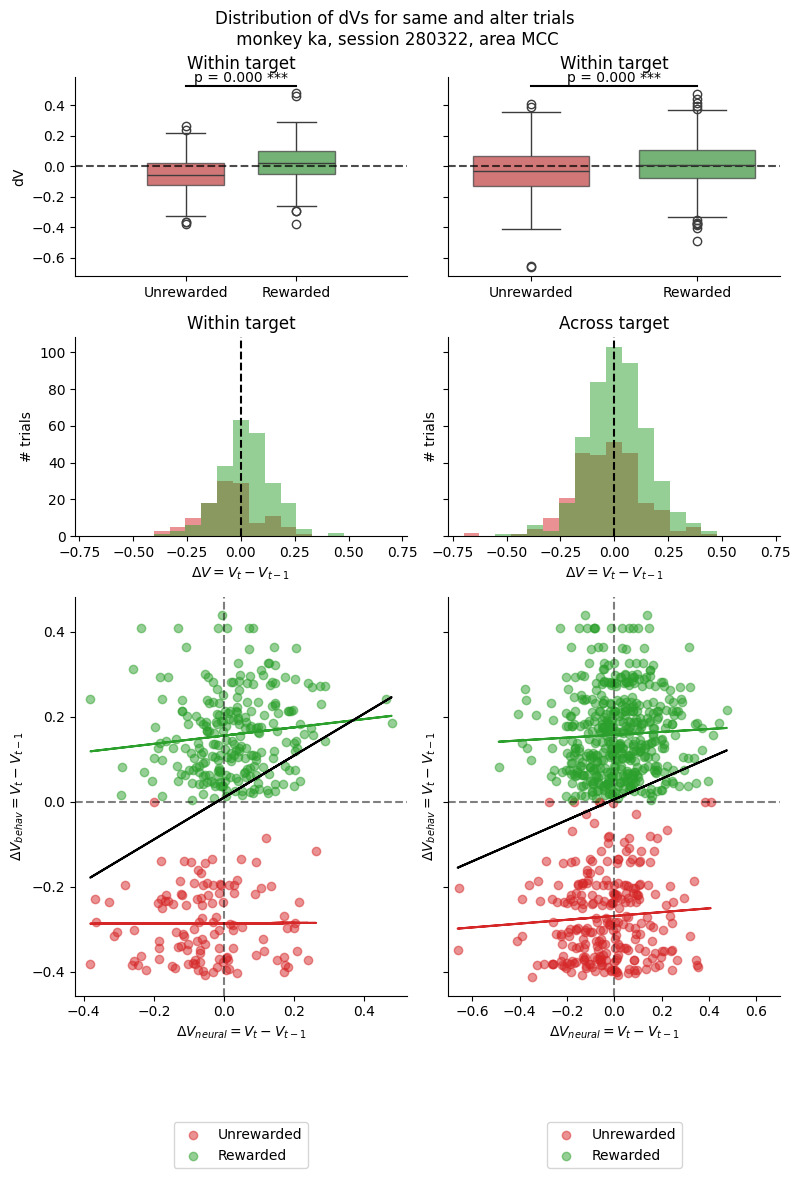

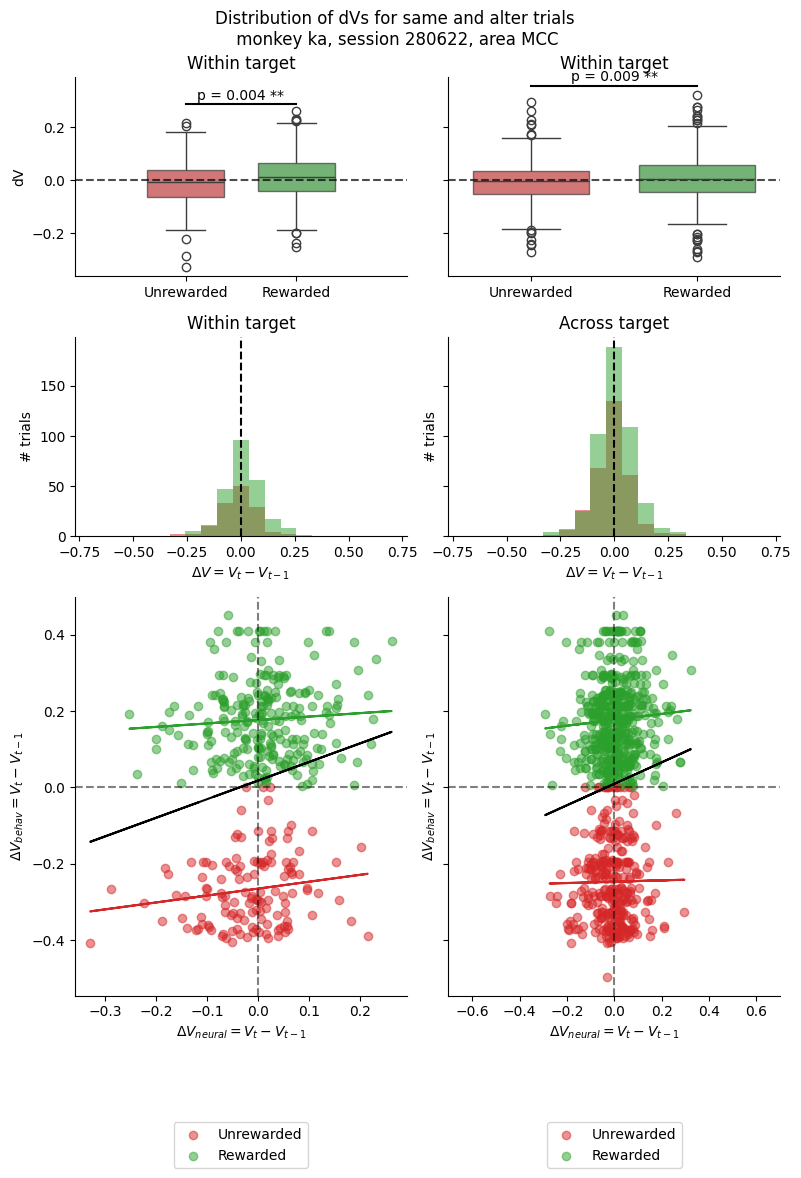

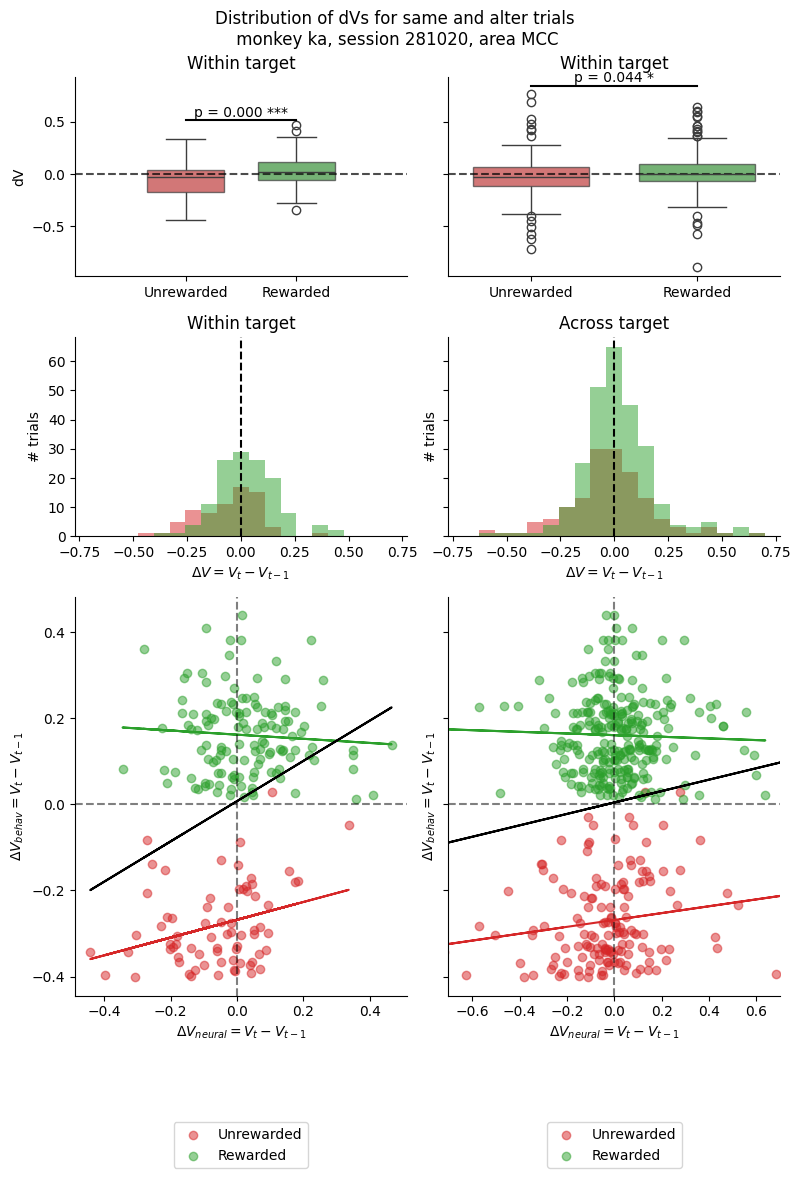

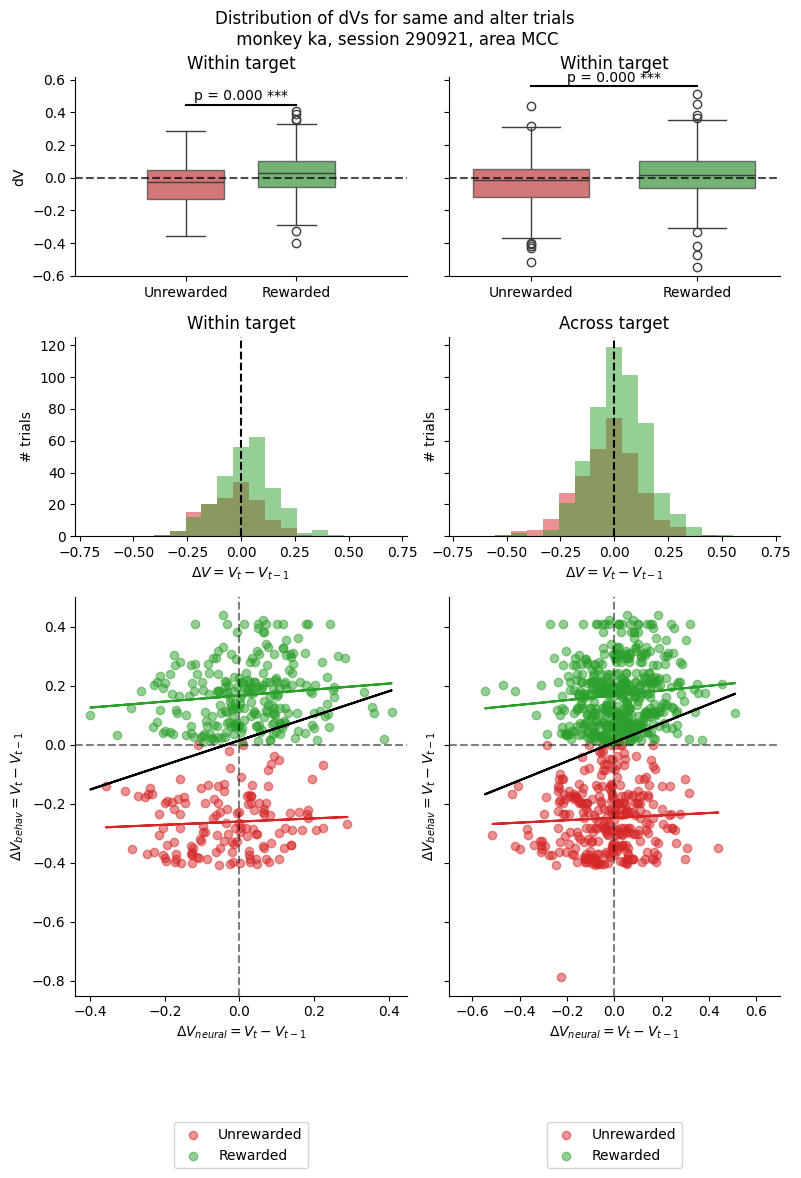

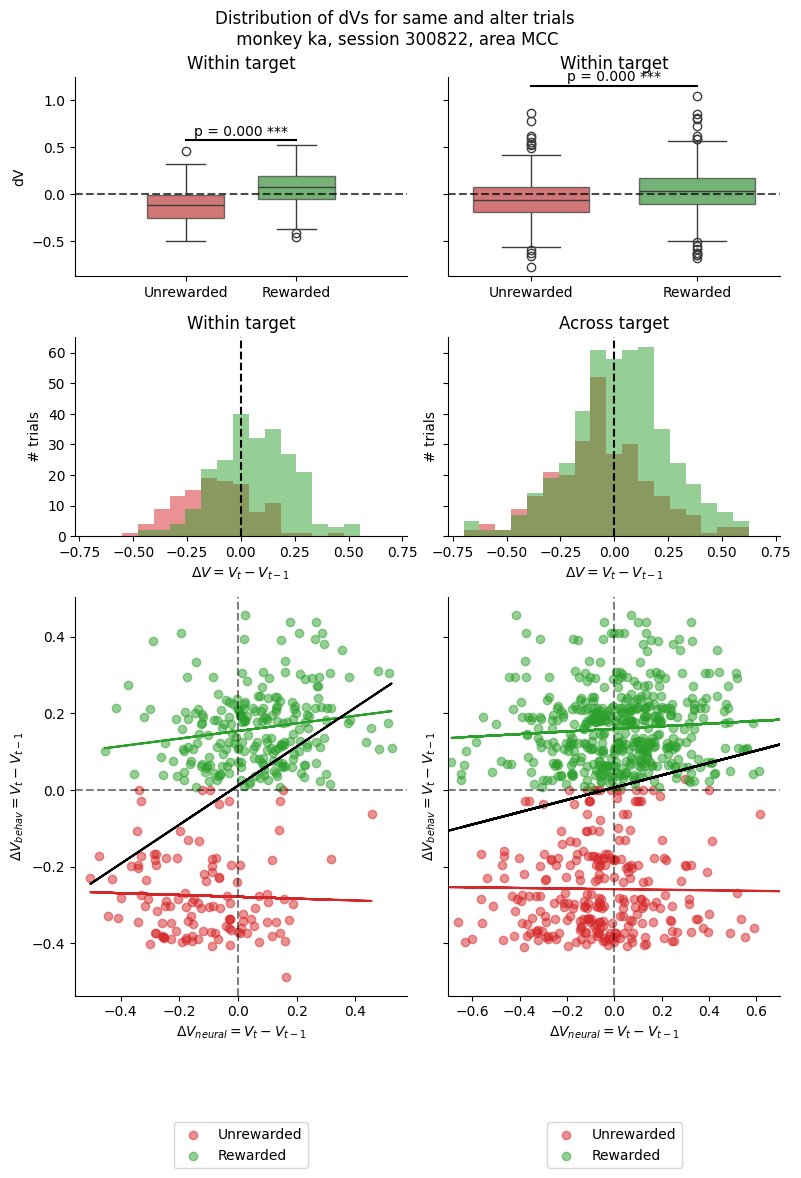

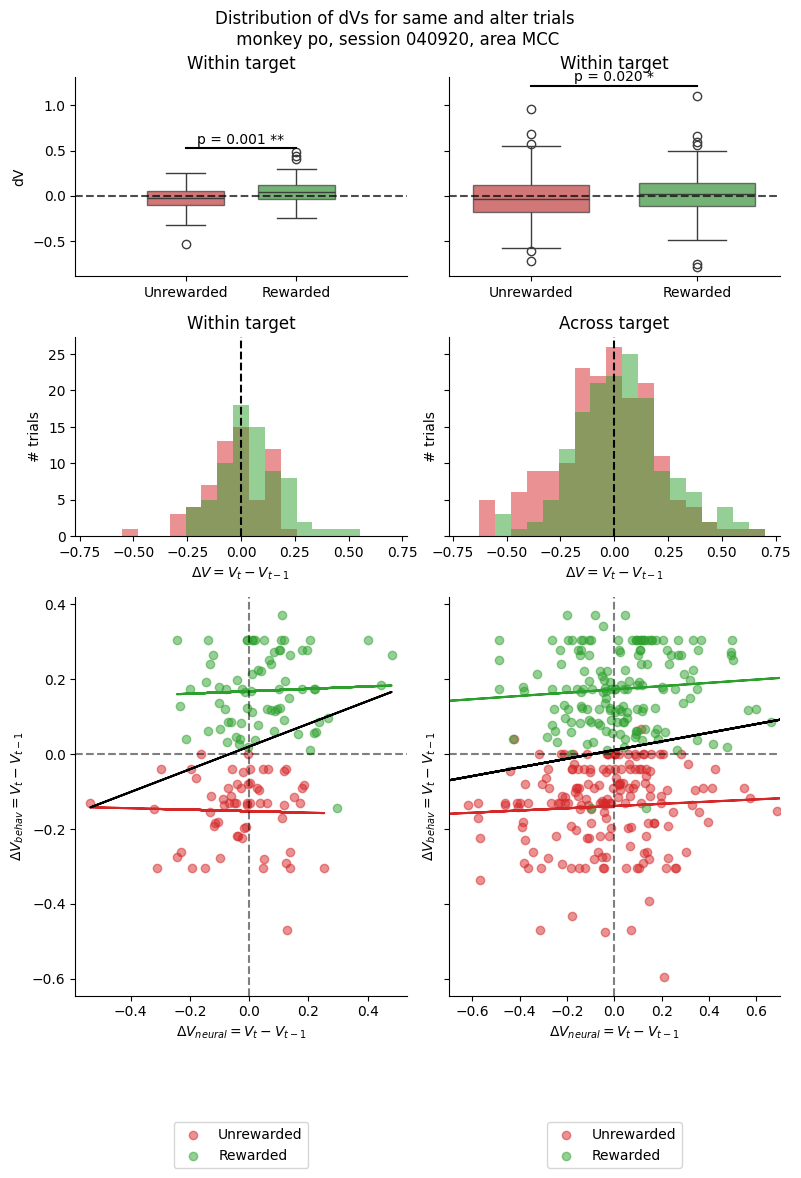

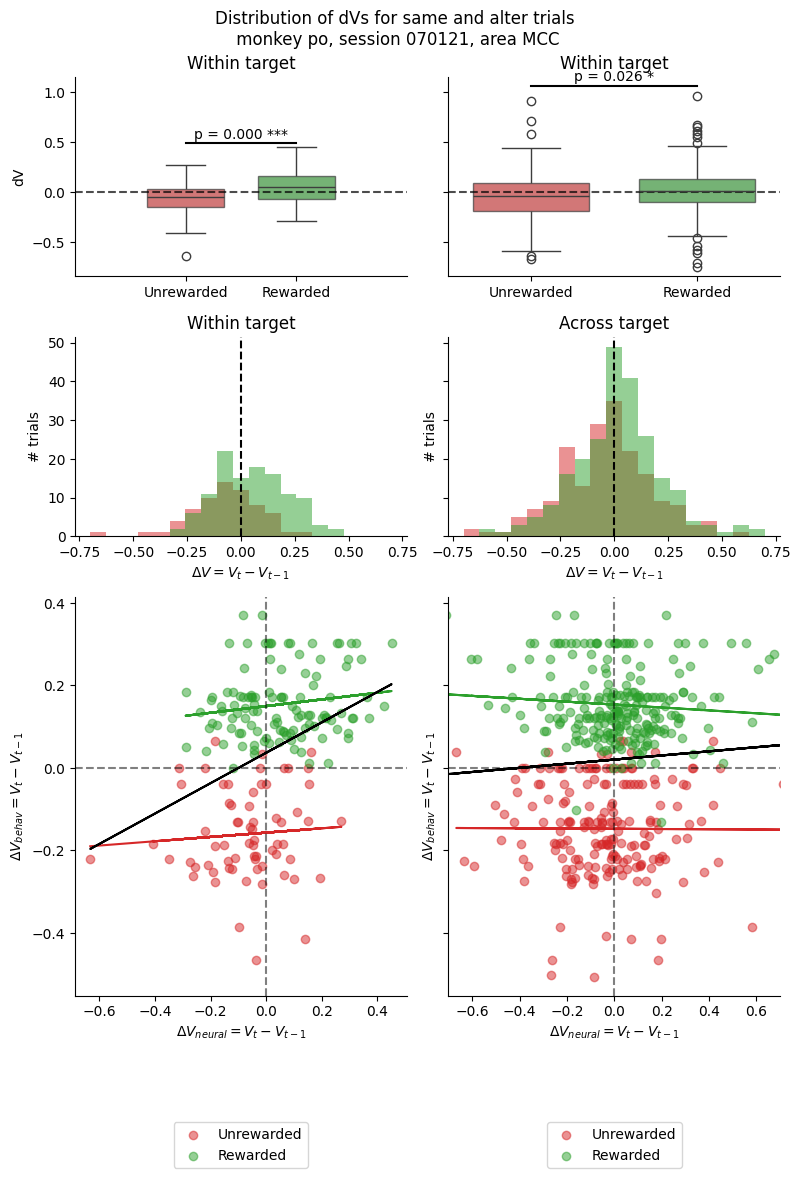

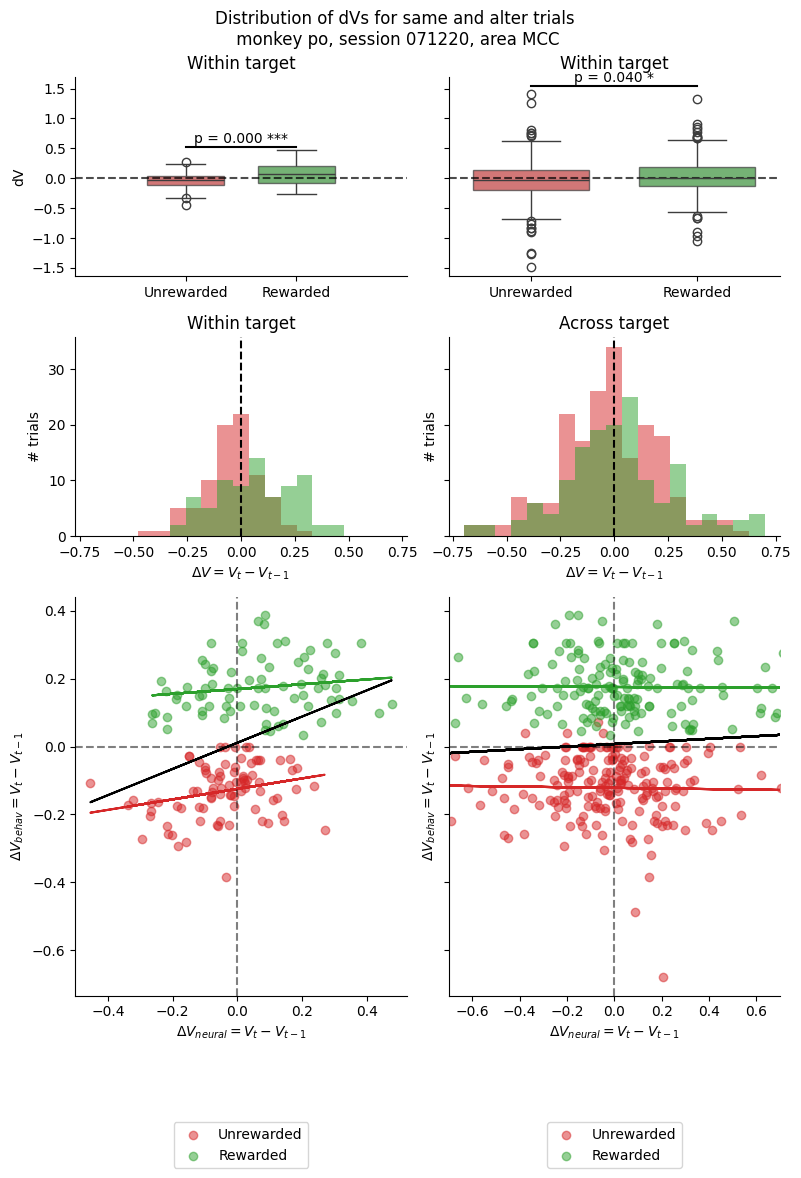

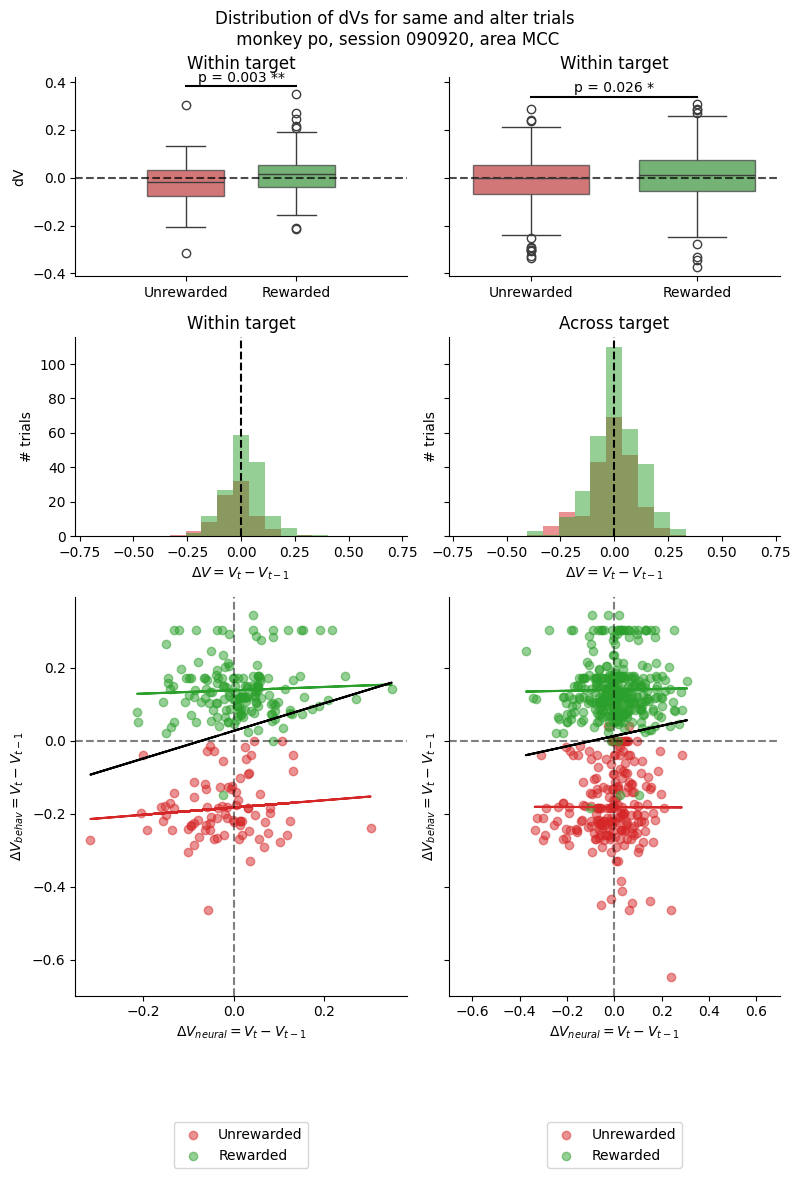

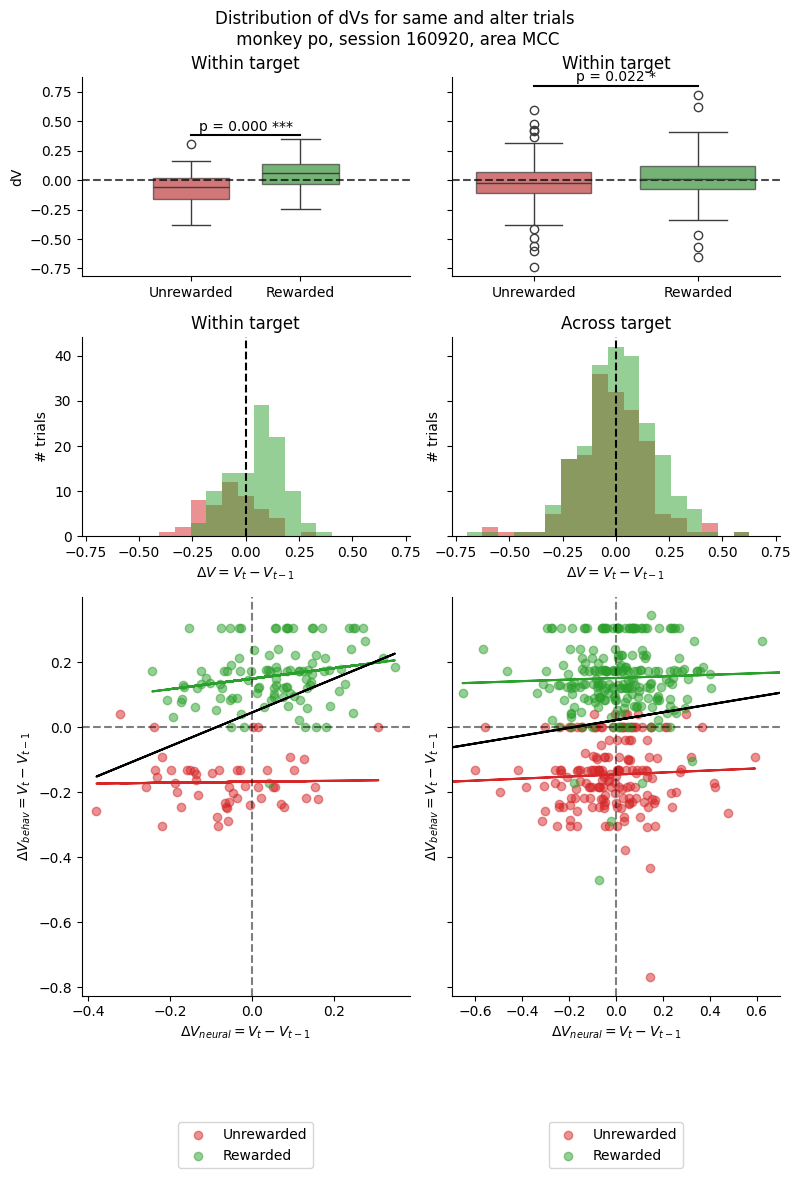

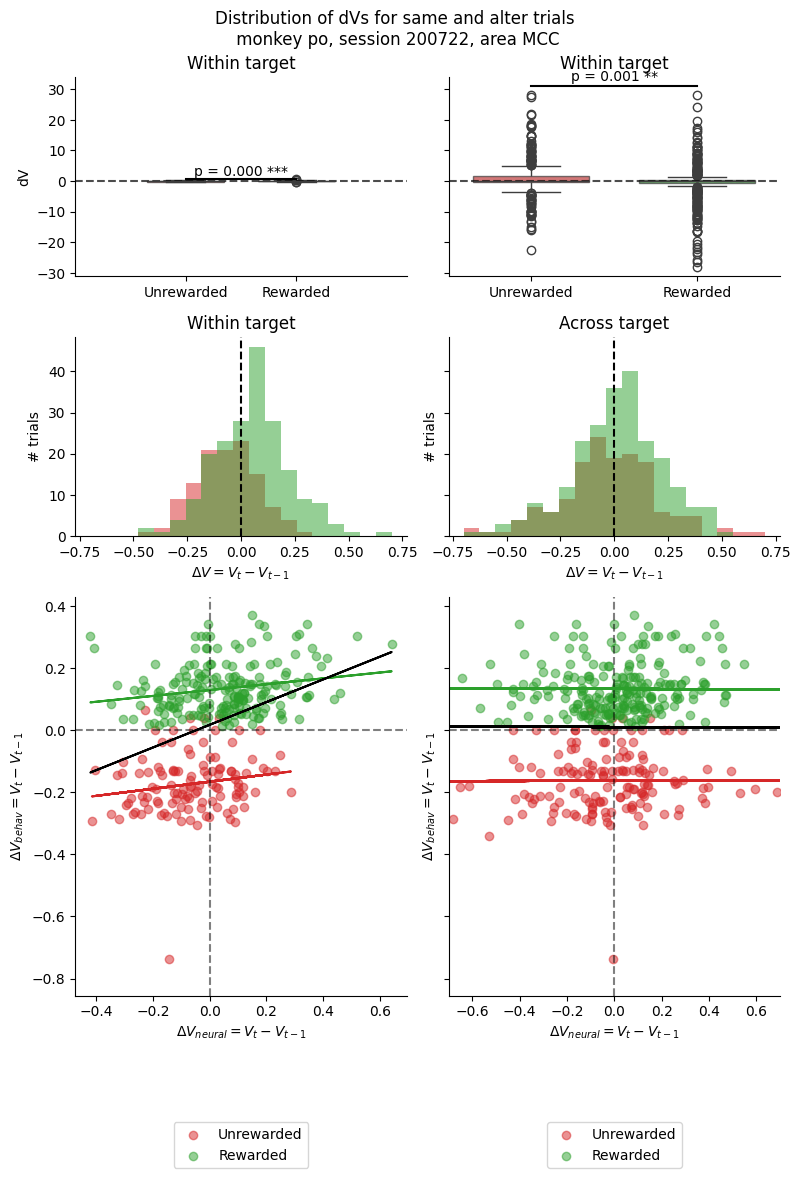

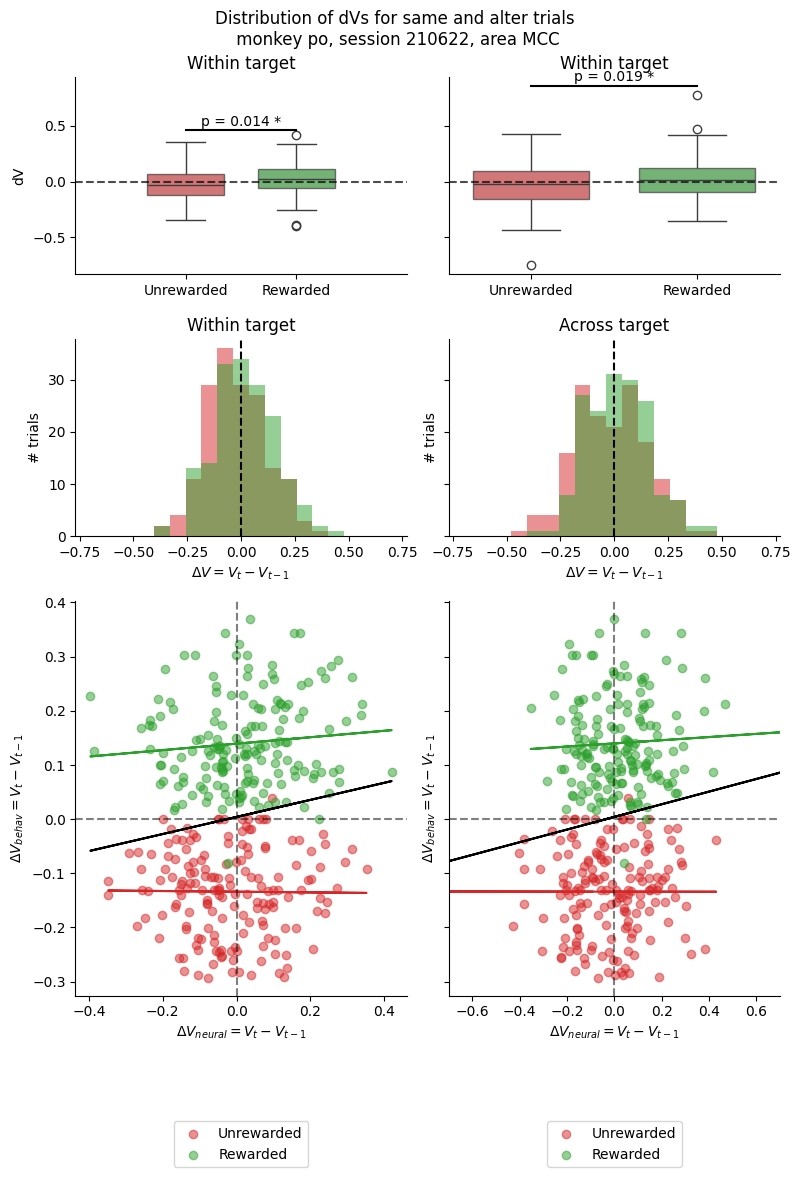

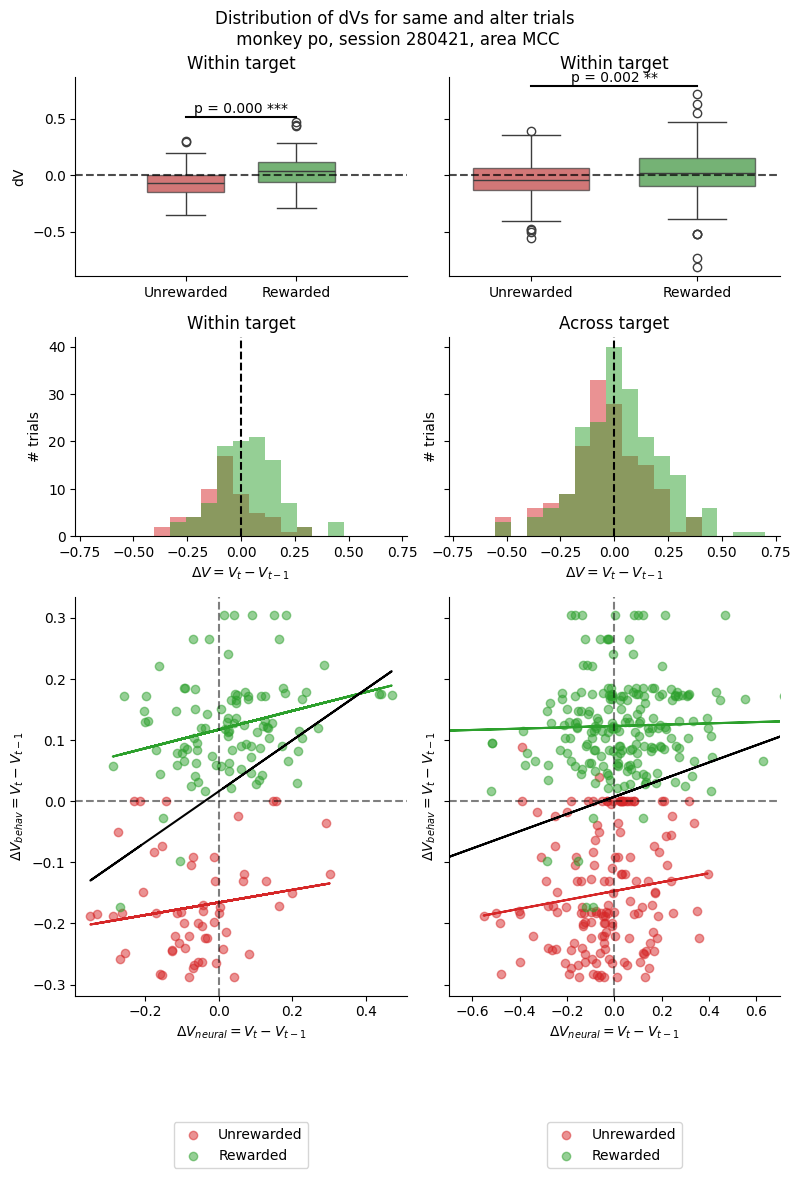

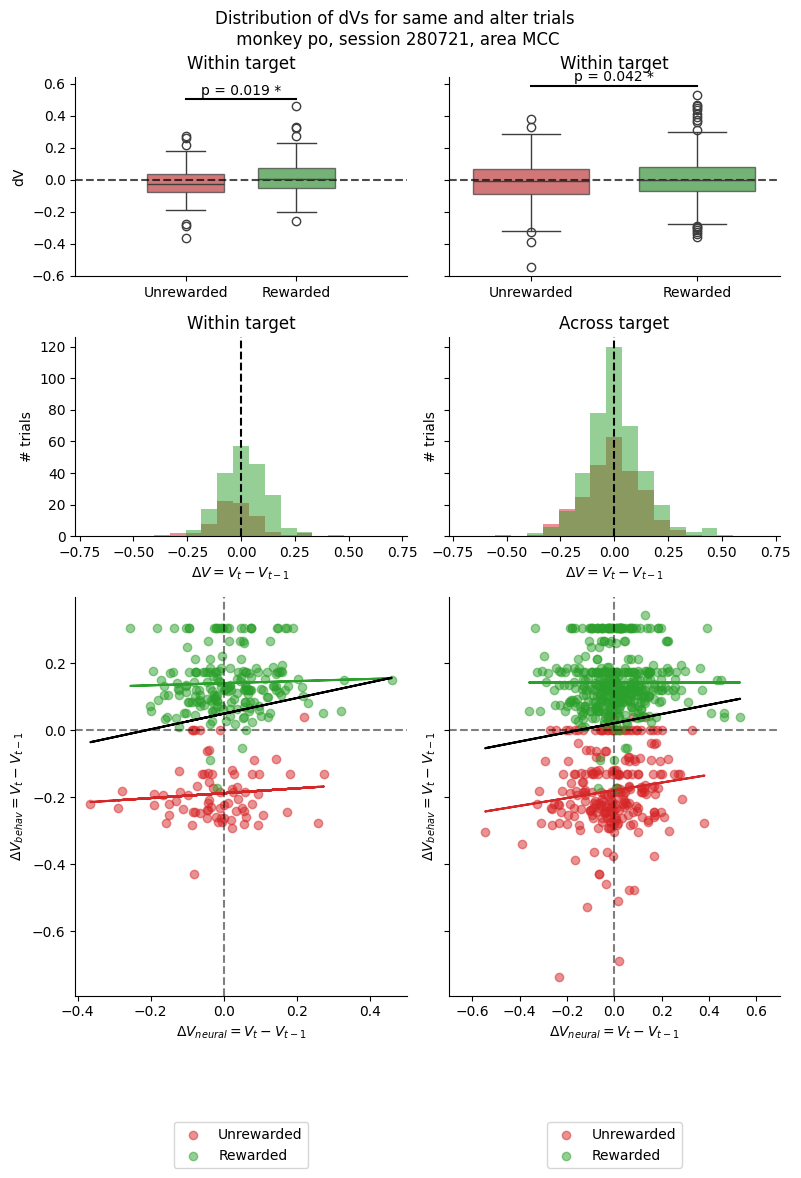

In [7]:

plim = .05
# print n sessions with p < .05 per monkey
for monkey in res.monkey.unique():
    for session in res.session.unique():
        p_val = res.loc[(res['monkey'] == monkey) & (res['session'] == session), 'p_value'].values
        if p_val < plim:
            results_df = results_df_all.loc[(results_df_all['monkey'] == monkey) & (results_df_all['session'] == session)]
                                
            plot_res_all(results_df, monkey, session, area='MCC')

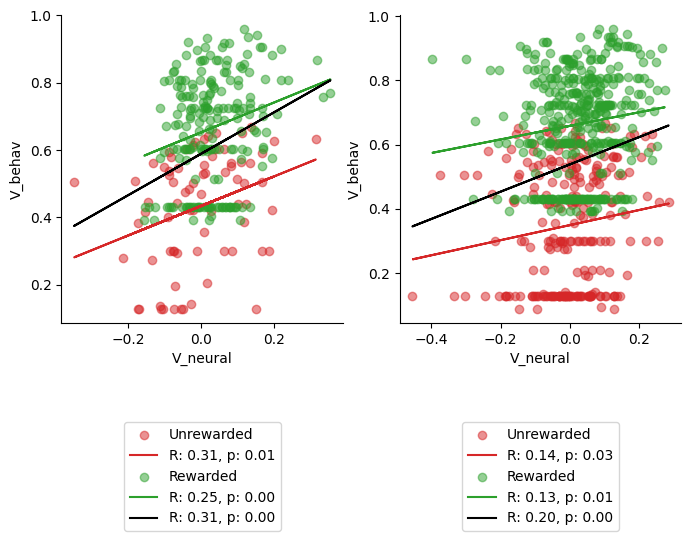

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))


ax = axs[0]
x_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'V_neural']
y_neg_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 0), 'V_behav']
ax.scatter(x_neg_within, y_neg_within, color='tab:red', alpha=.5, label='Unrewarded')
line = np.polyfit(x_neg_within, y_neg_within, 1)
corr, pval = stats.pearsonr(x_neg_within, y_neg_within)
ax.plot(x_neg_within, line[0] * x_neg_within + line[1], color='tab:red', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

x_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'V_neural']
y_pos_within = results_df.loc[(results_df['type'] == 'within') & (results_df['R_1'] == 1), 'V_behav']
ax.scatter(x_pos_within, y_pos_within, color='tab:green', alpha=.5, label='Rewarded')
line = np.polyfit(x_pos_within, y_pos_within, 1)
corr, pval = stats.pearsonr(x_pos_within, y_pos_within)
ax.plot(x_pos_within, line[0] * x_pos_within + line[1], color='tab:green', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')


x_all_within = results_df.loc[(results_df['type'] == 'within'), 'V_neural']
y_all_within = results_df.loc[(results_df['type'] == 'within'), 'V_behav']
line = np.polyfit(x_all_within, y_all_within, 1)
corr, pval = stats.pearsonr(x_all_within, y_all_within)
ax.plot(x_all_within, line[0] * x_all_within + line[1], color='black', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

ax.set_xlabel('V_neural')
ax.set_ylabel('V_behav')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axs[1]
x_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'V_neural']
y_neg_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 0), 'V_behav']
ax.scatter(x_neg_alter, y_neg_alter, color='tab:red', alpha=.5, label='Unrewarded')
line = np.polyfit(x_neg_alter, y_neg_alter, 1)
corr, pval = stats.pearsonr(x_neg_alter, y_neg_alter)
ax.plot(x_neg_alter, line[0] * x_neg_alter + line[1], color='tab:red', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

x_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'V_neural']
y_pos_alter = results_df.loc[(results_df['type'] == 'alter') & (results_df['R_1'] == 1), 'V_behav']
ax.scatter(x_pos_alter, y_pos_alter, color='tab:green', alpha=.5, label='Rewarded')
line = np.polyfit(x_pos_alter, y_pos_alter, 1)
corr, pval = stats.pearsonr(x_pos_alter, y_pos_alter)
ax.plot(x_pos_alter, line[0] * x_pos_alter + line[1], color='tab:green', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

x_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'V_neural']
y_all_alter = results_df.loc[(results_df['type'] == 'alter'), 'V_behav']
line = np.polyfit(x_all_alter, y_all_alter, 1)
corr, pval = stats.pearsonr(x_all_alter, y_all_alter)
ax.plot(x_all_alter, line[0] * x_all_alter + line[1], color='black', alpha=1, label=f'R: {corr:.2f}, p: {pval:.2f}')

ax.set_xlabel('V_neural')
ax.set_ylabel('V_behav')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)